## Latency Metrics

In [1]:
from experiment_analysis import load_experiment_latencies

# Load experiment 3 from ./experiments/3
df = load_experiment_latencies(exp_id=42, experiments_root="/home/data/saeid/experiments")
df.head()
df.describe(percentiles=[0.5, 0.9, 0.99])[[
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]]


,end_to_end_s
count,18213.000000
mean,71.302542
std,132.079527
min,0.038300
50%,23.745030
90%,185.419368
99%,742.302252
max,1196.604320


In [2]:
df

,idx,req_id,send_failed,end_to_end_s,model_latency_s,finish_reason,prompt_tokens,completion_tokens,total_tokens,ttft_s,tpot_avg_s,streaming,endpoint_id
0,0,bed0842b35d94d38b7c3a25afbb49e24,False,14.58906,14.58906,tool_calls,132670,75,None,3.98497,0.14330,True,vllm-minimax-m2-0
1,1,406169dd77884f0abab9ae49de21c1c8,False,79.07232,79.07232,stop,43865,407,None,1.17212,0.19187,True,vllm-minimax-m2-0
2,2,afbef6ad21fb4f869df0d34b7851de31,False,5.93291,5.93291,tool_calls,98035,62,None,1.58335,0.07130,True,vllm-minimax-m2-1
3,3,fca5cb0ee3d24bf8946a65e5931651e5,False,116.56533,116.56533,stop,157169,560,None,16.40222,0.17918,True,vllm-minimax-m2-0
4,4,999e2ea8d5d947878335728f4312c391,False,418.61858,418.61858,tool_calls,79092,3282,None,11.45028,0.12410,NaN,vllm-minimax-m2-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18208,18208,a333768e218245dba0e04571f1576667,False,29.42372,29.42372,stop,282,476,None,0.65291,0.06057,True,vllm-minimax-m2-0
18209,18209,24db04f54be44960bb015d187824472f,False,74.69509,74.69509,stop,355,1241,None,0.62724,0.05973,True,vllm-minimax-m2-0
18210,18210,593988eaf8c147bdacb153f45300de1b,False,112.77551,112.77551,stop,96484,1007,None,10.91254,0.10126,True,vllm-minimax-m2-0
18211,18211,2f62e80e24cb4231af969207eeed853a,False,6.74438,6.74438,tool_calls,100811,87,None,1.47126,0.06132,True,vllm-minimax-m2-0


In [3]:
from experiment_analysis import experiments_from_series

In [4]:
from experiment_analysis import load_experiment_latencies
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [46]

print(experiments)
# ----------------------------------------------

# Latency columns of interest
cols = [
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id, experiments_root="/home/data/saeid/experiments")

    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )

    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison

series_ids = [35]

[46]


[46]

Average latencies per experiment:

[time_offsets] APPLY_TIME_OFFSETS=True

Experiment 46:
  client_to_router_s          :      nan s
  router_queue_s              :      nan s
  router_to_sidecar_s         :      nan s
  sidecar_queue_s             :      nan s
  vllm_compute_s              :      nan s
  sidecar_post_s              :      nan s
  sidecar_to_router_s         :      nan s
  router_post_result_s        :      nan s
  SUM (components)            :    0.000 s

  Router post-result breakdown:
    router_result_handler_s   :      nan s
    router_wakeup_s           :      nan s
    router_response_build_s   :      nan s
    router_after_return_stamp_s:      nan s
    SUM (post breakdown)      : 0.000000 s

  end_to_end_s                :   76.727 s



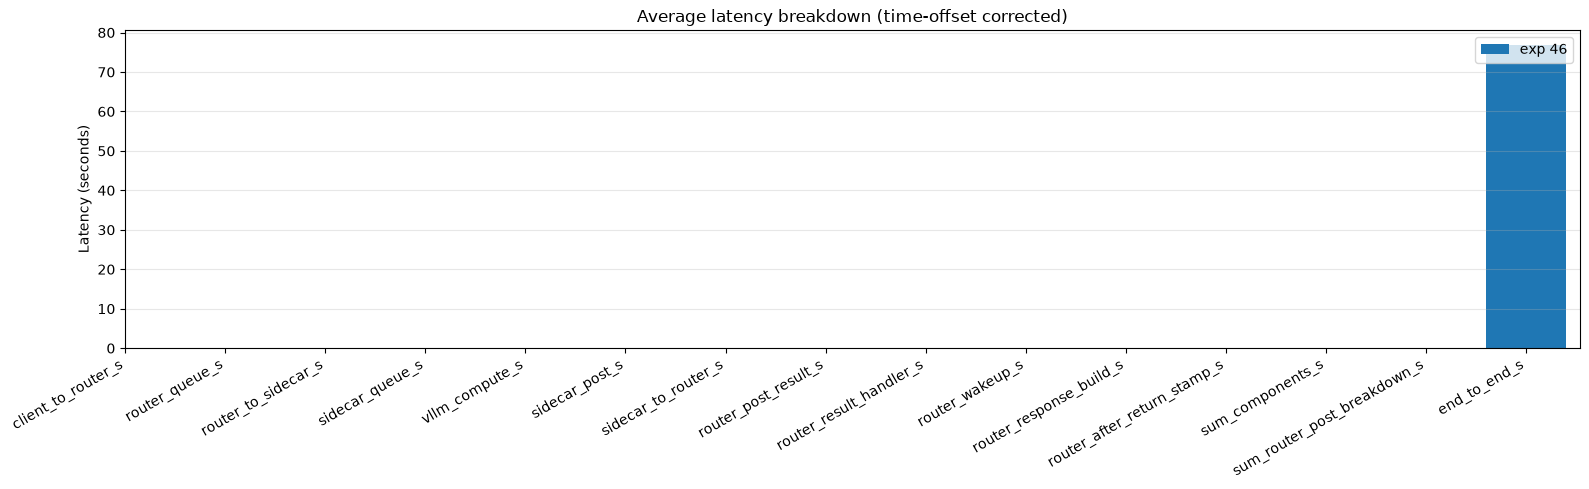

In [5]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt
import numpy as np

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [46]
print(experiments)
# ---------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# Non-overlapping latency components (base)
component_cols = [
    "client_to_router_s",
    "router_queue_s",
    "router_to_sidecar_s",
    "sidecar_queue_s",
    "vllm_compute_s",
    "sidecar_post_s",
    "sidecar_to_router_s",
    "router_post_result_s",
]

# router post-result breakdown (should sum ~ router_post_result_s when present)
router_post_breakdown_cols = [
    "router_result_handler_s",     # time spent inside /result handler (very small normally)
    "router_wakeup_s",             # waiter unblocked -> wait_for_result returns
    "router_response_build_s",     # build/merge trace/rename fields
    "router_after_return_stamp_s", # any last stamp after response object prepared (if you keep it)
]

extra_component_cols = [
    # keep empty unless you explicitly expose more metrics columns
]

e2e_col = "end_to_end_s"

plot_cols = (
    component_cols
    + router_post_breakdown_cols
    + extra_component_cols
    + ["sum_components_s", "sum_router_post_breakdown_s", e2e_col]
)

avg_by_exp = {}

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        apply_time_offset_correction=APPLY_TIME_OFFSETS,
        experiments_root="/home/data/saeid/experiments"
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    # Base component means
    comp_means = df.reindex(columns=component_cols).mean(numeric_only=True)
    sum_components = float(comp_means.sum(skipna=True))

    # Router post breakdown means
    post_means = df.reindex(columns=router_post_breakdown_cols).mean(numeric_only=True)
    sum_post_breakdown = float(post_means.sum(skipna=True))

    # Optional extras
    extra_means = df.reindex(columns=extra_component_cols).mean(numeric_only=True)

    e2e_mean = float(df[e2e_col].mean()) if e2e_col in df.columns else float("nan")

    row = {}

    for k in component_cols:
        row[k] = float(comp_means.get(k, np.nan))

    for k in router_post_breakdown_cols:
        row[k] = float(post_means.get(k, np.nan))

    for k in extra_component_cols:
        row[k] = float(extra_means.get(k, np.nan))

    row["sum_components_s"] = sum_components
    row["sum_router_post_breakdown_s"] = sum_post_breakdown
    row[e2e_col] = e2e_mean

    avg_by_exp[exp_id] = row

# ---- print numbers ----
print("\nAverage latencies per experiment:\n")
print(f"[time_offsets] APPLY_TIME_OFFSETS={APPLY_TIME_OFFSETS}\n")

for exp_id in experiments:
    r = avg_by_exp[exp_id]
    print(f"Experiment {exp_id}:")

    for k in component_cols:
        print(f"  {k:28s}: {r[k]:8.3f} s")

    print(f"  {'SUM (components)':28s}: {r['sum_components_s']:8.3f} s")
    print()

    print("  Router post-result breakdown:")
    for k in router_post_breakdown_cols:
        print(f"    {k:26s}: {r[k]:8.6f} s")
    print(f"    {'SUM (post breakdown)':26s}: {r['sum_router_post_breakdown_s']:8.6f} s")

    base_post = r.get("router_post_result_s", np.nan)
    if not (np.isnan(base_post) or np.isnan(r["sum_router_post_breakdown_s"])):
        diff = base_post - r["sum_router_post_breakdown_s"]
        print(f"    {'router_post_result_s':26s}: {base_post:8.6f} s")
        print(f"    {'DIFF (base - sum)':26s}: {diff:8.6f} s")
    print()

    print(f"  {e2e_col:28s}: {r[e2e_col]:8.3f} s")
    print()

# ---- grouped bar plot ----
labels = plot_cols
x = np.arange(len(labels))
width = 0.8 / max(1, len(experiments))

plt.figure(figsize=(16, 5))

for i, exp_id in enumerate(experiments):
    vals = [avg_by_exp[exp_id].get(k, np.nan) for k in labels]
    plt.bar(x + i * width, vals, width, label=f"exp {exp_id}")

plt.xticks(
    x + width * (len(experiments) - 1) / 2,
    labels,
    rotation=30,
    ha="right"
)
plt.ylabel("Latency (seconds)")
plt.title(
    "Average latency breakdown (time-offset corrected)"
    if APPLY_TIME_OFFSETS
    else "Average latency breakdown (raw clocks)"
)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
from experiment_analysis import load_experiment_latencies
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [46]
print(experiments)

# ----------------------------------------------

# Latency columns of interest
cols = [
    "end_to_end_s",
    "ttft_s"
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    df = df.iloc[20:]
    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )

    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison


[46]


,exp46_end_to_end_s,exp46_ttft_s
count,33771.000000,33744.000000
mean,76.769512,4.530889
std,114.830767,18.648860
min,0.047280,0.047280
50%,41.374380,1.413930
90%,180.030430,9.865156
99%,596.636895,41.435541
max,1192.209570,977.753420


In [7]:
# from experiment_analysis import load_experiment_latencies
# import pandas as pd
# # ---- choose experiments (exclude first 20 entries) ----
# # choose which series you want
# # series_ids = [35]
# # experiments = experiments_from_series(series_ids)
# experiments = [46]
# print(experiments)
# # ----------------------------------------------
# # Latency columns of interest
# cols = [
#     "end_to_end_s",
#     # "server_roundtrip_s",
#     # "router_queue_s",
#     # "vllm_compute_s",
# ]
# percentiles = [0.5, 0.9, 0.99]
# summaries = []
# for exp_id in experiments:
#     df = load_experiment_latencies(exp_id=exp_id)
#     df = df.iloc[20:]
#     summary = (
#         df.describe(percentiles=percentiles)[cols]
#           .add_prefix(f"exp{exp_id}_")
#     )
#     summaries.append(summary)
# # Combine all experiments side-by-side
# comparison = pd.concat(summaries, axis=1)
# comparison


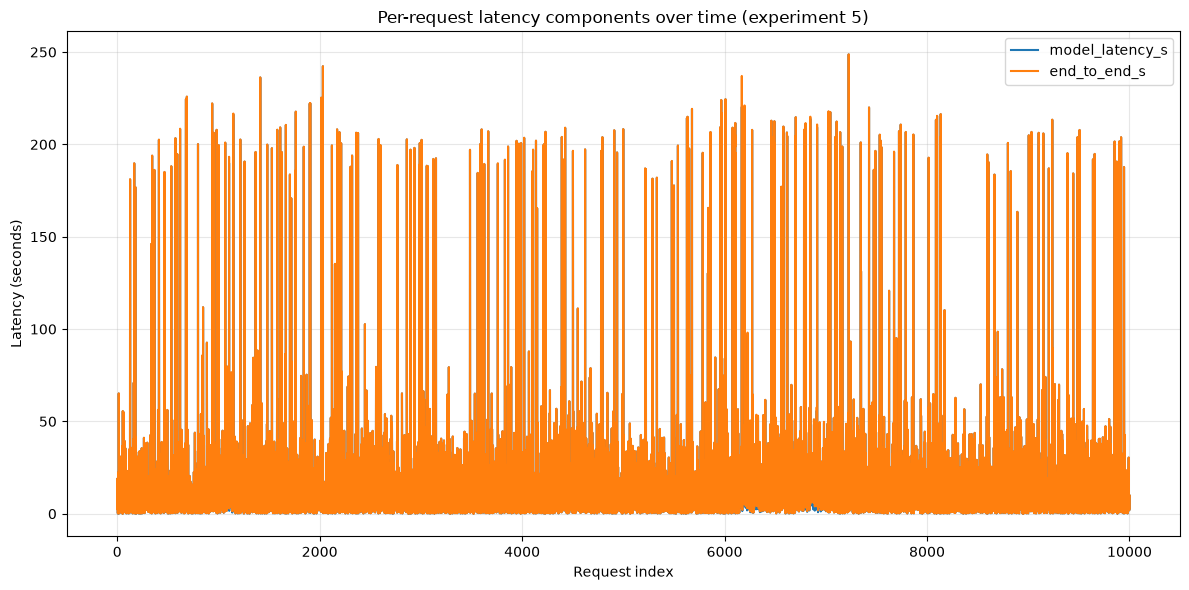

In [8]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiment ----
exp_id = 5
# ---------------------------

# Load and order by request index (or any monotonic field you prefer)
df = load_experiment_latencies(
    exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments").sort_values("idx").reset_index(drop=True)

# X-axis: request index (0, 1, 2, ...)
x = df["idx"]

# Latency metrics to plot over time
latency_cols = [
    "model_latency_s",
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "router_to_sidecar_s",
    # "sidecar_queue_s",
    # "vllm_compute_s",
]

plt.figure(figsize=(12, 6))

for col in latency_cols:
    if col in df.columns:
        plt.plot(x, df[col], label=col)

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(f"Per-request latency components over time (experiment {exp_id})")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


[46]


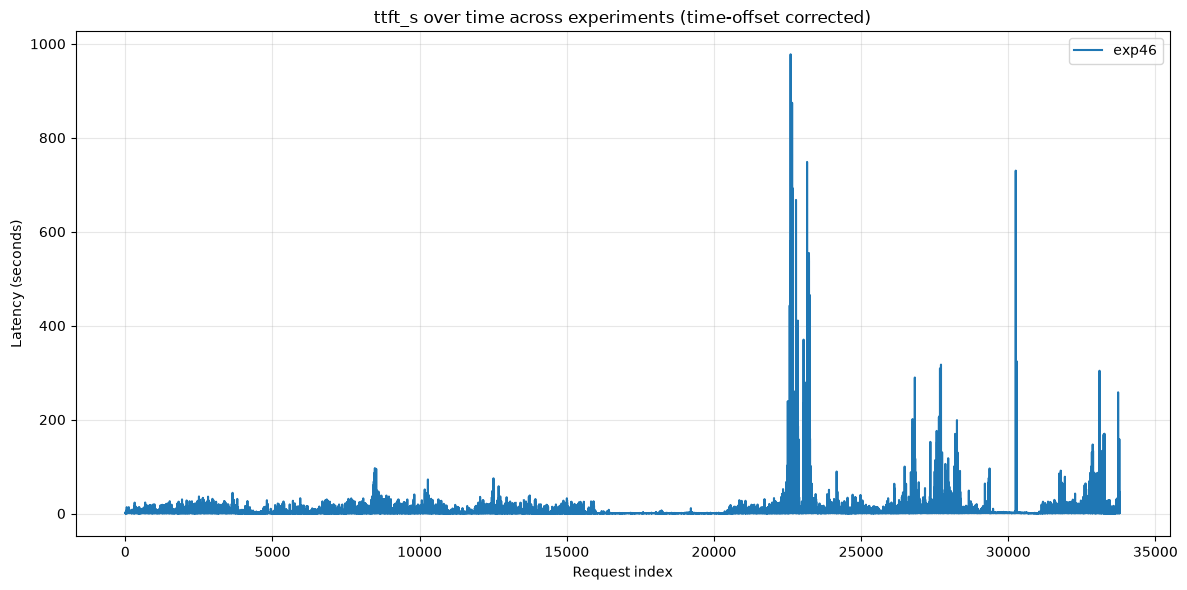

In [9]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [46]

print(experiments)
# ----------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "end_to_end_s"          # total client → router → server → client
metric = "ttft_s"
# metric = "server_roundtrip_s"  # router → vLLM → router
# metric = "router_queue_s"      # waiting time in router queue
# metric = "router_to_sidecar_s" # router → sidecar hop
# metric = "sidecar_queue_s"     # waiting time inside sidecar
# metric = "vllm_compute_s"      # actual model compute time
# metric = "router_post_result_s"
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
            experiments_root="/home/data/saeid/experiments"
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(
    f"{metric} over time across experiments "
    + ("(time-offset corrected)" if APPLY_TIME_OFFSETS else "(raw clocks)")
)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Throughput Metrics

In [10]:
# Split the sum and mean group based on metric characteristics.
# SLO violation for TTFT and TPOT, can be customised based on the target SLO. For Qwen3-8B model, assume the SLO for TTFT is 500ms, for TPOT is 50 ms

from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [46]
print(experiments)
# ----------------------------------------------

# Prometheus metric columns of interest
# (these are the fields inside each "samples" object in metrics.jsonl)

# aggregated by SUM across instances per tick
sum_cols = [
    "gen_tokens_per_sec",
    # "prefill_tokens_per_sec",
    # "requests_running",       # sum = cluster total queue depth; use mean if single-instance or want per-instance avg
    # "requests_waiting",       # same as above
    # "request_success_per_sec",
    # "preemptions_per_sec",
    # --- prefix cache rates (sum across instances) ---
    # "prefix_cache_hits_per_sec",
    # "prefix_cache_queries_per_sec",
    # "ext_prefix_cache_hits_per_sec",
    # "ext_prefix_cache_queries_per_sec",
    # "prompt_tokens_cached_per_sec",
]

# aggregated by MEAN across instances per tick
# (these are pre-averaged histograms inside vLLM)
mean_cols = [
    # vLLM latency hist averages (if your vLLM exposes them)
    "ttft_seconds_avg",
    "tpot_seconds_avg",
    # "e2e_latency_seconds_avg",
    # "queue_time_seconds_avg",
    # "inference_time_seconds_avg",
    # "prefill_time_seconds_avg",
    # "decode_time_seconds_avg",

    # # token distribution hists (averages)
    # "request_prompt_tokens_avg",
    # "request_generation_tokens_avg",
    # "request_max_generation_tokens_avg",

    # # spec decode (optional)
    # "spec_tokens_accepted_per_sec",  # debatable: could be sum if you want cluster total
    # "spec_tokens_draft_per_sec",
    # "spec_tokens_emitted_per_sec",
    # "kv_cache_usage_perc",           # GPU KV cache usage (%)
    # "prefix_cache_hit_rate",         # derived: hits / queries
    # "ext_prefix_cache_hit_rate",     # derived: ext hits / ext queries
]

percentiles = [0.5, 0.9, 0.99]

# SLO thresholds
TTFT_SLO_S = 0.500  # 500ms in seconds
TPOT_SLO_S = 0.050  # 50ms in seconds

summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    # ---- CLUSTER VIEW (recommended): sum across instances per tick ----
    valid_sum_cols  = [c for c in sum_cols  if c in prom.columns]
    valid_mean_cols = [c for c in mean_cols if c in prom.columns]

    missing = set(sum_cols + mean_cols) - set(prom.columns)
    if missing:
        print(f"[WARN] exp{exp_id}: columns not found in prom, skipping: {missing}")

    agg_sum  = prom.groupby("ts")[valid_sum_cols].sum(min_count=1).reset_index()
    agg_mean = prom.groupby("ts")[valid_mean_cols].mean().reset_index()
    agg = agg_sum.merge(agg_mean, on="ts", how="outer")

    # Describe only the columns that actually exist in agg
    valid_all_cols = [c for c in (sum_cols + mean_cols) if c in agg.columns]
    summary = (
        agg[valid_all_cols]
        .describe(percentiles=percentiles)
        .add_prefix(f"exp{exp_id}_")
    )

    # ---- SLO compliance: % of ticks where metric is within SLO ----
    # NaN ticks (no completed requests) are excluded from both numerator and denominator
    if "ttft_seconds_avg" in agg.columns:
        ttft_col = agg["ttft_seconds_avg"].dropna()
        ttft_slo_pct = (ttft_col <= TTFT_SLO_S).mean() * 100
    else:
        ttft_slo_pct = float("nan")

    if "tpot_seconds_avg" in agg.columns:
        tpot_col = agg["tpot_seconds_avg"].dropna()
        tpot_slo_pct = (tpot_col <= TPOT_SLO_S).mean() * 100
    else:
        tpot_slo_pct = float("nan")

    # Build SLO row — NaN for all cols without a defined SLO
    slo_data = {f"exp{exp_id}_{c}": float("nan") for c in valid_all_cols}
    slo_data[f"exp{exp_id}_ttft_seconds_avg"] = ttft_slo_pct
    slo_data[f"exp{exp_id}_tpot_seconds_avg"] = tpot_slo_pct
    slo_row = pd.DataFrame(slo_data, index=["SLO_COMPLIANCE_%"])

    summary = pd.concat([summary, slo_row])
    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)
comparison

[46]
[WARN] exp46: columns not found in prom, skipping: {'tpot_seconds_avg'}


,exp46_gen_tokens_per_sec,exp46_ttft_seconds_avg,exp46_tpot_seconds_avg
count,6175.000000,5365.000000,NaN
mean,188.404695,7.504977,NaN
std,76.959418,85.573783,NaN
min,0.000000,0.290510,NaN
50%,171.965517,1.497919,NaN
90%,299.075862,8.680470,NaN
99%,400.405517,67.358747,NaN
max,576.965517,3877.571729,NaN
SLO_COMPLIANCE_%,NaN,0.410065,NaN


[46]


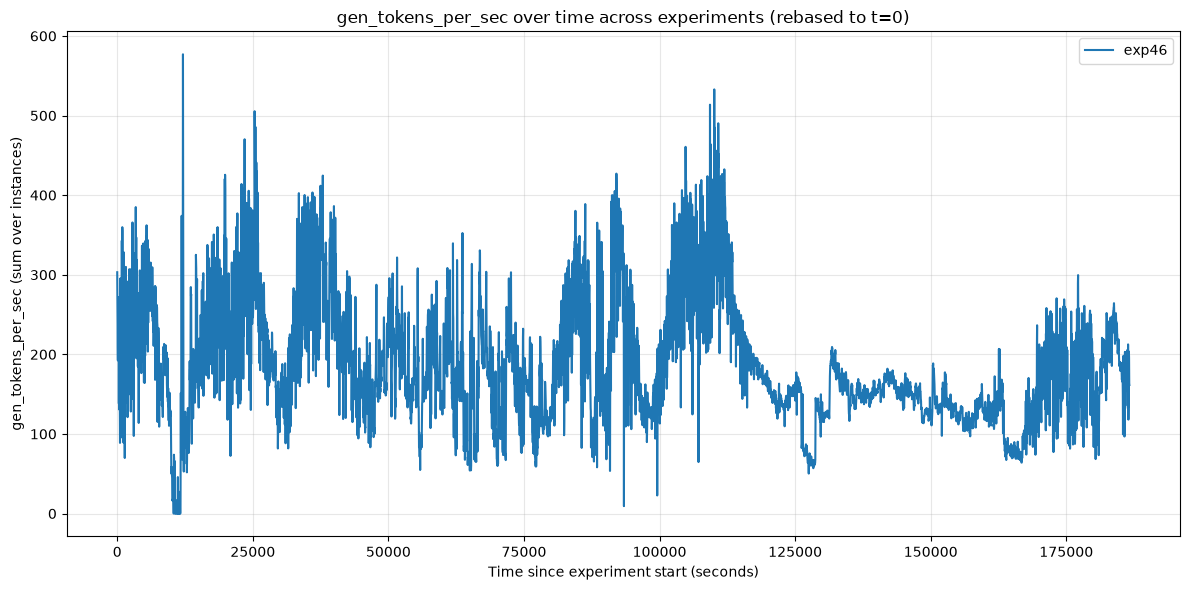

In [11]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [46]

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "requests_running"
metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "request_success_per_sec"
# metric = "preemptions_per_sec"
# metric = "kv_cache_usage_perc"
# metric = "requests_waiting"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# metric = "queue_time_seconds_avg"
# metric = "inference_time_seconds_avg"
# metric = "prefill_time_seconds_avg"
# metric = "decode_time_seconds_avg"
# metric = "request_prompt_tokens_avg"
# metric = "request_generation_tokens_avg"
# metric = "request_max_generation_tokens_avg"
# metric = "spec_tokens_accepted_per_sec"
# metric = "spec_tokens_draft_per_sec"
# metric = "spec_tokens_emitted_per_sec"
# --- prefix cache metrics ---
# metric = "prefix_cache_hits_per_sec"
# metric = "prefix_cache_queries_per_sec"
# metric = "prefix_cache_hit_rate"
# metric = "ext_prefix_cache_hits_per_sec"
# metric = "ext_prefix_cache_queries_per_sec"
# metric = "ext_prefix_cache_hit_rate"
# metric = "prompt_tokens_cached_per_sec"
# --- router histogram percentiles ---
# metric = "router_ttft_p50"
# metric = "router_ttft_p95"
# metric = "router_tpot_avg_p50"
# metric = "router_tpot_avg_p95"
# metric = "router_e2e_p50"
# metric = "router_e2e_p95"

# -----------------------------------------------

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Rebase time: each experiment starts at t=0
    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick
    if agg_mode == "sum":
        series = prom.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances)"
    else:
        series = prom.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances)"

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


## Token Length Distribution

[46]


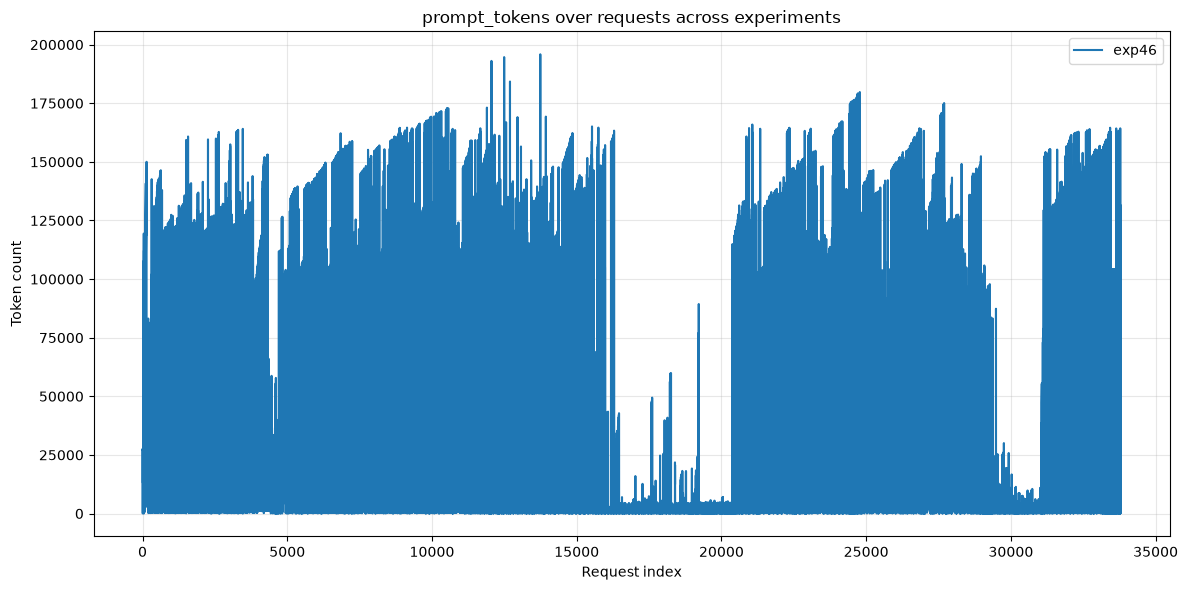

In [12]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [46]

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
metric = "prompt_tokens"        # input length
# metric = "completion_tokens"  # output length
# metric = "total_tokens"       # input + output
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            experiments_root="/home/data/saeid/experiments")
        .sort_values("idx")
        .reset_index(drop=True)
    )

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Token count")
plt.title(f"{metric} over requests across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [13]:
from experiment_analysis import load_experiment_latencies

experiments = [46]

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    total = df["total_tokens"].sum()
    print(f"exp{exp_id}: {total} total tokens")

exp46: 0 total tokens


[46]


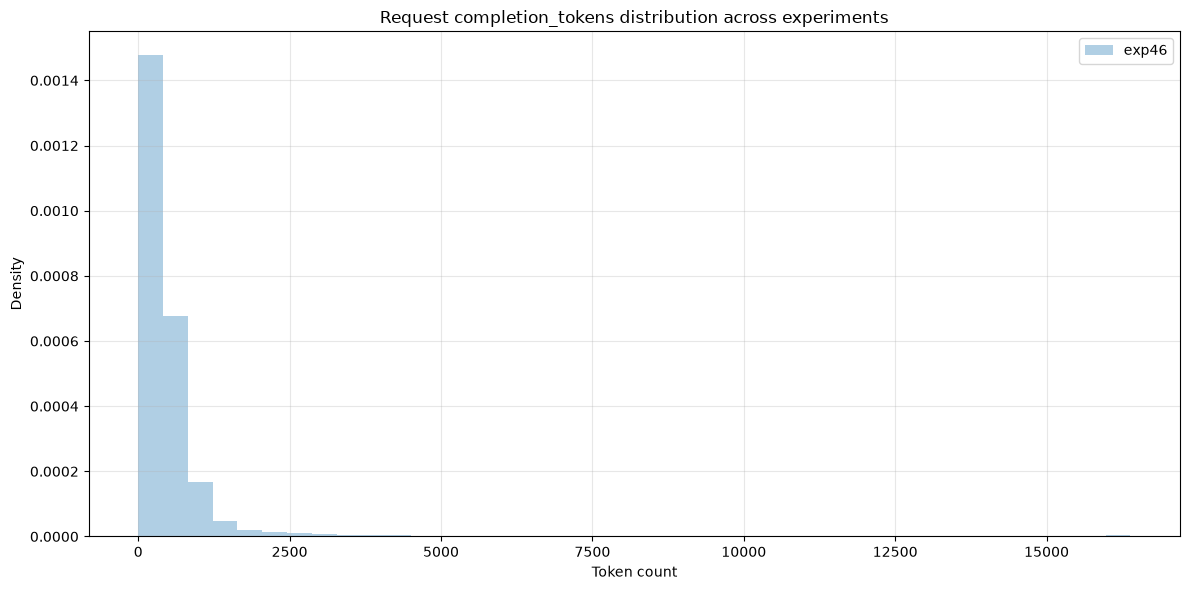

In [14]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [46]

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length distribution
metric = "completion_tokens"  # output length distribution
# metric = "total_tokens"       # input + output distribution
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    values = pd.to_numeric(df[metric], errors="coerce").dropna()
    if values.empty:
        print(f"Skipping exp{exp_id}: {metric} all NaN")
        continue

    plt.hist(
        values,
        bins=40,
        density=True,     # normalize so experiments are comparable
        alpha=0.35,
        label=f"exp{exp_id}",
    )

plt.xlabel("Token count")
plt.ylabel("Density")
plt.title(f"Request {metric} distribution across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [15]:
from pathlib import Path
import json
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [46]

print(experiments)
# ----------------------------


def count_requests(exp_id, experiments_root="/home/data/saeid/experiments"):
    exp_dir = Path(experiments_root) / str(exp_id)
    logs_path = exp_dir / "logs.json"

    if not logs_path.exists():
        raise FileNotFoundError(f"logs.json not found for experiment {exp_id}")

    total = 0
    success = 0
    send_failed = 0

    with logs_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)
            total += 1

            if rec.get("send_failed", False):
                send_failed += 1
            else:
                success += 1

    return {
        "experiment": exp_id,
        "total_requests": total,
        "successful_requests": success,
        "connection_failed_requests": send_failed,
        "success_rate_pct": 100.0 * success / total if total > 0 else 0.0,
        "failure_rate_pct": 100.0 * send_failed / total if total > 0 else 0.0,
    }


rows = []
for exp_id in experiments:
    rows.append(count_requests(exp_id))

df_counts = pd.DataFrame(rows)
df_counts


[46]


,experiment,total_requests,successful_requests,connection_failed_requests,success_rate_pct,failure_rate_pct
0,46,33792,33792,0,100.0,0.0


In [16]:
from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [46]

print(experiments)
# ----------------------------------------------

percentiles = [0.5, 0.9, 0.99]

# ============================================================
# METRICS ONLY (the ones we added ourselves)
# Choose ONE:
#   "router_only"   -> only router metrics (from :8080 rows)
#   "sidecar_only"  -> only sidecar metrics (from :8200 rows)
#   "all_new"       -> both router + sidecar (two views, same table)
# ============================================================

METRICS_MODE = "all_new"  # <- change me

ROUTER_COLS = [
    "router_queue_length",
    "router_admission_rps",
    "router_outgoing_rps",
]

SIDECAR_COLS = [
    "sidecar_queue_length",
    "sidecar_received_rps",
    "sidecar_completed_rps",
    # "sidecar_workers_total",
    # "sidecar_workers_busy",
    # "sidecar_python_threads",
]

MODE_TO_COLS = {
    "router_only": ROUTER_COLS,
    "sidecar_only": SIDECAR_COLS,
    "all_new": ROUTER_COLS + SIDECAR_COLS,
}

if METRICS_MODE not in MODE_TO_COLS:
    raise ValueError(f"Unknown METRICS_MODE={METRICS_MODE!r}. Choose one of: {sorted(MODE_TO_COLS)}")

SELECT_COLS = MODE_TO_COLS[METRICS_MODE]


def _port_of_instance(inst: str):
    """Extract port from instance strings like '1.2.3.4:8200' or '1.2.3.4:8200:0' (DP engine suffix)."""
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None


def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()


def _summarize_raw_cluster(df: pd.DataFrame, cols: list[str], exp_id: int) -> pd.DataFrame | None:
    """
    Cluster-view: aggregate across instances per tick, then describe across time.
    (No "coverage" output; just raw stats.)
    """
    if df.empty:
        return None

    cols = [c for c in cols if c in df.columns]
    if not cols:
        return None

    # per-tick aggregate across instances
    agg = df.groupby("ts")[cols].sum(min_count=1)

    # drop ticks where everything is missing (prevents NaN-only describe rows)
    agg = agg.dropna(how="all", subset=cols)
    if agg.empty:
        return None

    # if a metric is missing at some ticks, treat as 0 (keeps describe() clean)
    agg[cols] = agg[cols].fillna(0.0)

    # IMPORTANT: prefix ONLY with exp id (no redundant "sidecar_sidecar_*")
    return agg[cols].describe(percentiles=percentiles).add_prefix(f"exp{exp_id}_")


summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments")

    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    router_df = _subset_by_port(prom, 8080)
    vllm_df = _subset_by_port(prom, 8200)

    if METRICS_MODE == "router_only":
        s = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s)

    elif METRICS_MODE == "sidecar_only":
        s = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s)

    else:  # all_new
        # Router metrics should come from router rows (:8080)
        s_router = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s_router is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s_router)

        # Sidecar metrics should come from vLLM rows (:8200) (where we mapped them)
        s_sidecar = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s_sidecar is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s_sidecar)

comparison = pd.concat(summaries, axis=1) if summaries else pd.DataFrame()
comparison


[46]
[WARN] exp46: no vLLM (:8200) samples found for sidecar_*


,exp46_router_queue_length,exp46_router_admission_rps,exp46_router_outgoing_rps
count,6175.00000,6175.000000,6175.000000
mean,0.00664,0.176518,0.082935
std,0.08319,0.159631,0.085773
min,0.00000,0.000000,0.000000
50%,0.00000,0.137931,0.068966
90%,0.00000,0.413793,0.206897
99%,0.00000,0.655172,0.344828
max,2.00000,1.137931,0.655172


[46]


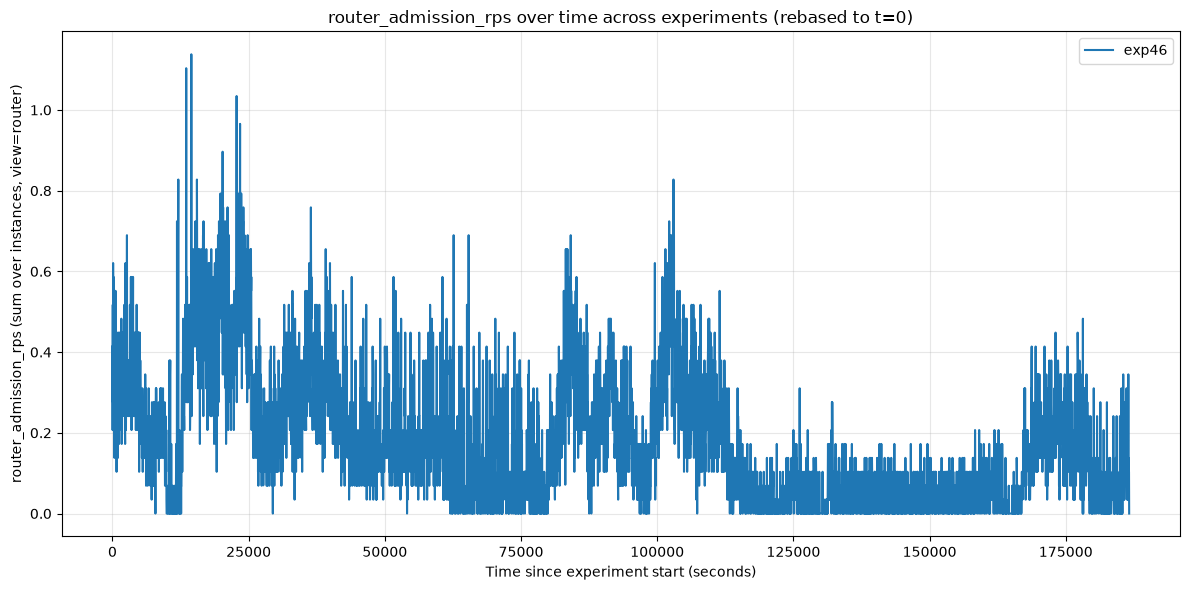

In [17]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [46]

print(experiments)
# ----------------------------

# ============================================================
# METRICS ONLY (router + sidecar)
# Choose ONE metric (uncomment exactly one)
# ============================================================

# --- Router metrics ---
# metric = "router_queue_length"
metric = "router_admission_rps"
# metric = "router_outgoing_rps"
# metric = "router_ttft_p50"
# metric = "router_ttft_p95"
# metric = "router_tpot_avg_p50"
# metric = "router_tpot_avg_p95"
# metric = "router_e2e_p50"
# metric = "router_e2e_p95"

# --- Sidecar metrics ---
# metric = "sidecar_queue_length"
# metric = "sidecar_received_rps"
# metric = "sidecar_completed_rps"
# metric = "sidecar_workers_total"
# metric = "sidecar_workers_busy"
# metric = "sidecar_python_threads"

# ============================================================
# Which "view" to plot?
#   - "router" : use :8080 rows (ground truth router pod)
#   - "vllm"   : use :8200 rows (broadcast router_* + mapped sidecar_*)
#
# Recommended:
#   - router_* -> view="router"
#   - sidecar_*-> view="vllm"
# ============================================================
view = "router"   # "router" or "vllm"

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"    # "sum" (cluster-level) or "mean" (per-instance average)
# ---------------------------------------------------------

def _port_of_instance(inst: str):
    """Extract port from instance strings like '1.2.3.4:8200' or '1.2.3.4:8200:0' (DP engine suffix)."""
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

# Auto-pick a sensible default view if user forgets
if view not in ("router", "vllm"):
    raise ValueError("view must be 'router' or 'vllm'")

if metric.startswith("sidecar_") and view == "router":
    print("[WARN] sidecar_* metrics live on vLLM (:8200) rows. Switching view -> 'vllm'.")
    view = "vllm"

if metric.startswith("router_") and view == "vllm":
    print("[NOTE] plotting router_* from vLLM (:8200) rows uses the broadcast values.")
    print("       If you want router ground-truth, set view='router'.")

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id, experiments_root="/home/data/saeid/experiments")

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Pick the right rows
    if view == "router":
        df = _subset_by_port(prom, 8080)
    else:
        df = _subset_by_port(prom, 8200)

    if df.empty:
        print(f"Skipping exp{exp_id}: no rows for view={view!r}")
        continue

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found in view={view!r}")
        continue

    # Rebase time: each experiment starts at t=0 within this view
    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick (NaNs ignored; if all NaN at tick -> NaN)
    if agg_mode == "sum":
        series = df.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances, view={view})"
    elif agg_mode == "mean":
        series = df.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances, view={view})"
    else:
        raise ValueError("agg_mode must be 'sum' or 'mean'")

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


[46]


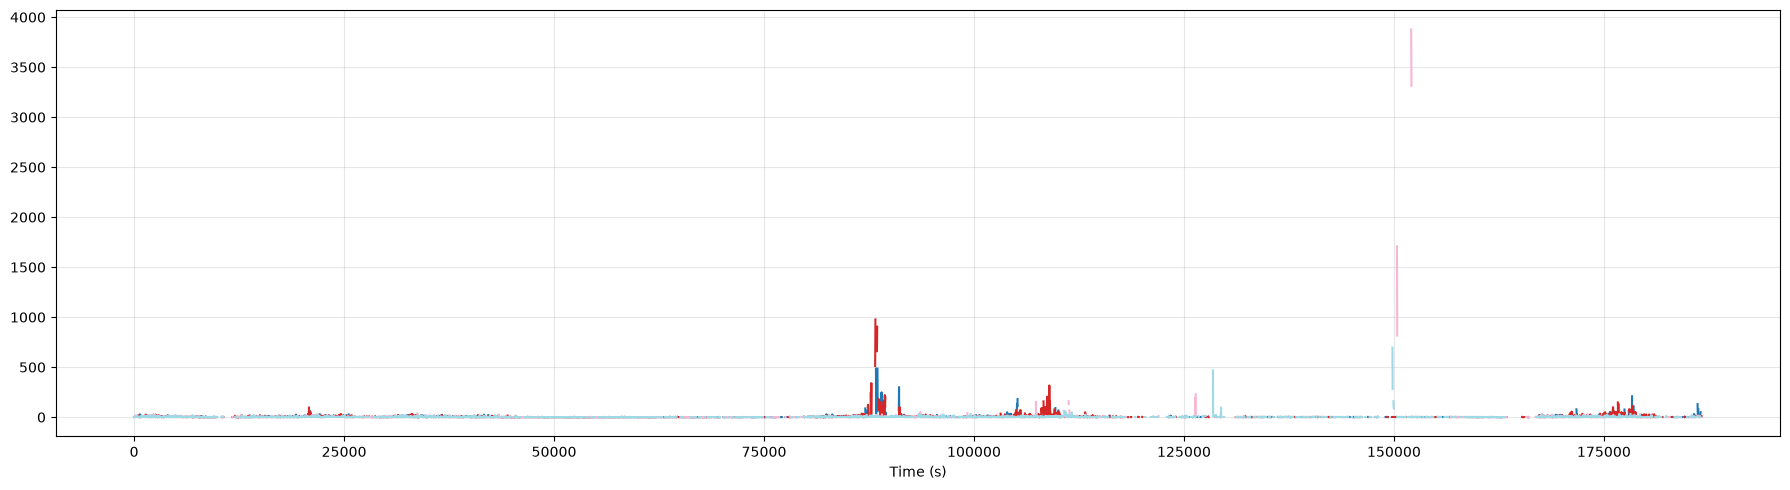

In [18]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import re
import os

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [46]
print(experiments)

# ============================================================
# Choose ONE metric (uncomment exactly one)
# ============================================================
# metric = "sidecar_queue_length"
# metric = "requests_running"
# metric = "requests_waiting"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "kv_cache_usage_perc"
# metric = "request_success_per_sec"
# metric = "preemptions_per_sec"
metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# --- prefix cache metrics ---
# metric = "prefix_cache_hits_per_sec"
# metric = "prefix_cache_queries_per_sec"
# metric = "prefix_cache_hit_rate"
# metric = "ext_prefix_cache_hits_per_sec"
# metric = "ext_prefix_cache_queries_per_sec"
# metric = "ext_prefix_cache_hit_rate"
# metric = "prompt_tokens_cached_per_sec"
view = "vllm"  # sidecar_* live on vLLM (:8200)


def _port_of_instance(inst: str):
    """Extract port from instance strings like '1.2.3.4:8200' or '1.2.3.4:8200:0' (DP engine suffix)."""
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

def _natural_key(s: str):
    parts = re.split(r"(\d+)", str(s))
    return [int(p) if p.isdigit() else p for p in parts]


# ------------------------------------------------------------
# FIRST PASS: load data + assign server1..serverN per experiment
# ------------------------------------------------------------
data_by_exp = {}
max_servers = 0

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)
    df = _subset_by_port(prom, 8200)

    if df.empty or metric not in df.columns:
        continue

    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    insts = sorted(df["instance"].dropna().unique().tolist(), key=_natural_key)
    slot_map = {inst: f"server{i+1}" for i, inst in enumerate(insts)}

    df = df.copy()
    df["server_slot"] = df["instance"].map(slot_map)

    data_by_exp[exp_id] = df
    max_servers = max(max_servers, len(insts))

# Canonical slot names
canonical_slots = [f"server{i}" for i in range(1, max_servers + 1)]

# ------------------------------------------------------------
# Consistent colors per slot
# ------------------------------------------------------------
cmap = plt.colormaps["tab20"].resampled(len(canonical_slots))
color_map = {slot: cmap(i) for i, slot in enumerate(canonical_slots)}

# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(experiments), figsize=(18, 5), sharey=True)
if len(experiments) == 1:
    axes = [axes]

for ax, exp_id in zip(axes, experiments):
    df = data_by_exp.get(exp_id)
    if df is None or df.empty:
        ax.grid(True, alpha=0.3)
        continue

    for slot, g in df.groupby("server_slot"):
        if slot not in color_map:
            continue
        g = g.sort_values("t_rel_s")
        ax.plot(
            g["t_rel_s"],
            g[metric],
            color=color_map[slot],
            linewidth=1.5,
        )

    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
os.makedirs("figures", exist_ok=True)
# plt.savefig(f"figures/{metric}_per_vllm_queue_comparison.png", dpi=300)

plt.show()


In [19]:
# ============================================================
# Reproduce the dashboard's "Backend Model TPS" ranking
# (verified to match the web page exactly)
#
# Algorithm = the page's updateTPSRanking:
#   seconds   = ts[-1] - ts[-2]
#   outputTps = (output_tokens[-1] - output_tokens[-2]) / seconds
#   totalTps  = ((out[-1]+in[-1]) - (out[-2]+in[-2])) / seconds
#   cache     = prefix_cache_hits_percent[-1]
#
# Data source: live API or a stored snapshot (toggle below)
# ============================================================
import json, glob, os, datetime as dt

# ---------- config ----------
USE_LIVE = False   # True = hit the live API to reproduce the current ranking
                  # False = compute from the latest stored snapshot
LIVE_URL = "http://10.44.142.113:9999/zhongruan_api/api/data/1hour"
SNAP_GLOB = "/home/data/saeid/experiments_hq/1/*api_data_*.json"  # used when USE_LIVE=False
# ----------------------------

def parse_ts(s):
    """Parse a timestamp string from the API into a datetime."""
    for fmt in ("%Y-%m-%dT%H:%M", "%Y-%m-%dT%H:%M:%S", "%Y-%m-%d %H:%M", "%Y-%m-%d %H:%M:%S"):
        try: return dt.datetime.strptime(s, fmt)
        except (ValueError, TypeError): continue
    return None

def load_data():
    """Load the data JSON either from the live API or the newest snapshot."""
    if USE_LIVE:
        import urllib.request
        with urllib.request.urlopen(LIVE_URL, timeout=20) as r:
            return json.load(r)
    else:
        f = sorted(glob.glob(SNAP_GLOB))[-1]   # newest snapshot
        print(f"Reading snapshot: {os.path.basename(f)}")
        return json.load(open(f, encoding="utf-8"))

def fmt_tps(v):
    """Replicate the page's formatTPS: >=1e6 -> M, >=1e3 -> K, else raw."""
    if v >= 1e6: return f"{v/1e6:.1f}M token/s"
    if v >= 1e3: return f"{v/1e3:.1f}K token/s"
    return f"{v:.1f} token/s"

def backend_tps_ranking(data):
    """Compute the backend-model TPS ranking exactly as the dashboard does."""
    timestamps = data.get("timestamps") or []
    idm = data.get("identifier_metrics") or {}
    if len(timestamps) < 2:
        print("Fewer than 2 time points; cannot compute."); return []

    # Time delta between the last two datapoints (in seconds)
    last_ts, prev_ts = parse_ts(timestamps[-1]), parse_ts(timestamps[-2])
    seconds = (last_ts - prev_ts).total_seconds()
    if seconds <= 0:
        print("Non-positive time delta."); return []

    items = []
    for ident, m in idm.items():
        if "gateway" in ident.lower():          # the page filters out gateway
            continue
        out = m.get("output_tokens") or []
        inp = m.get("input_tokens") or []
        if len(out) < 2:
            continue
        # Pure output TPS: delta of cumulative output tokens / time delta
        last_out, prev_out = out[-1] or 0, out[-2] or 0
        out_diff = last_out - prev_out
        if out_diff <= 0:                        # page rule: no output -> not ranked
            continue
        # Total TPS: delta of (output + input) tokens / time delta
        last_in  = (inp[-1] if len(inp) >= 1 else 0) or 0
        prev_in  = (inp[-2] if len(inp) >= 2 else 0) or 0
        total_diff = (last_out + last_in) - (prev_out + prev_in)

        # Cache hit rate: latest value of the prefix cache hit percentage
        cache_arr = m.get("prefix_cache_hits_percent") or []
        cache = cache_arr[-1] if cache_arr else None

        items.append({
            "name": ident,
            "output_tps": out_diff / seconds,
            "total_tps": total_diff / seconds if total_diff > 0 else 0.0,
            "cache": cache,
        })
    items.sort(key=lambda x: x["output_tps"], reverse=True)   # sort by output TPS desc
    return items, last_ts, prev_ts, seconds

# ---------- run ----------
data = load_data()
result = backend_tps_ranking(data)
if result:
    items, last_ts, prev_ts, seconds = result
    print(f"Time window: {prev_ts:%Y-%m-%d %H:%M} -> {last_ts:%H:%M}  ({seconds:.0f}s)\n")
    print(f"{'#':>2} {'model':<32} {'output token/s':>14} | {'total token/s':>14} | cache")
    print("-" * 80)
    for i, it in enumerate(items, 1):
        cache_str = f"{it['cache']:.1f}%" if it["cache"] is not None else "—"
        print(f"{i:>2} {it['name']:<32} {fmt_tps(it['output_tps']):>14} | "
              f"{fmt_tps(it['total_tps']):>14} | {cache_str}")

Reading snapshot: 20260627_141117_zhongruan_api_api_data_24hour.json
Time window: 2026-06-27 14:00 -> 14:11  (660s)

 # model                            output token/s |  total token/s | cache
--------------------------------------------------------------------------------
 1 GLM-5.1-direct100                 622.8 token/s |  80.6K token/s | 9.8%
 2 MiniMax-M2.7-llmla1-direct65       87.7 token/s |   3.3K token/s | 40.6%
 3 MiniMax-M2.7-direct202             85.4 token/s |  11.4K token/s | 56.7%
 4 MiniMax-M2.7-llmla2-direct65       65.2 token/s |   2.9K token/s | 16.8%
 5 Qwen3.5-direct225                  48.5 token/s |   2.8K token/s | 81.0%
 6 MiniMax-M2.7-direct142             31.6 token/s |   6.9K token/s | 51.8%
 7 Qwen3.5-direct155                  10.1 token/s |   2.1K token/s | 75.8%


In [20]:
# ============================================================
# Cell 0 — shared loader + series builders (run this first)
# TPS  : web algorithm = (output_tokens[i]-output_tokens[i-1]) / (ts[i]-ts[i-1])
# cache: total prefix cache hit rate = total_cache_hits_percent[i] (latest per point)
# All later cells reuse these helpers.
# ============================================================
import json, glob, os, datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------- config ----------
SNAP_GLOB = "/home/data/saeid/experiments_hq/1/*api_data_*.json"
GAP_SECONDS = 20 * 60   # break the line if two points are more than this apart

# Models to plot (edit as needed)
MODELS = [
    "MiniMax-M2.7-llmla1-direct65",
    "MiniMax-M2.7-llmla2-direct65",
    "MiniMax-M2.7-direct142",
    "MiniMax-M2.7-direct202",
]

# Display-name mapping: raw model name -> label shown on every plot/legend/bar
LABELS = {
    "MiniMax-M2.7-llmla1-direct65": "llm-la-1",
    "MiniMax-M2.7-llmla2-direct65": "llm-la-2",
    "MiniMax-M2.7-direct142":       "boomgateway-1",
    "MiniMax-M2.7-direct202":       "boomgateway-pd",
}
def label_of(m):
    """Map a raw model name to its display label (falls back to the raw name)."""
    return LABELS.get(m, m)
# ----------------------------

def parse_ts(s):
    """Parse an API timestamp string into a datetime."""
    for fmt in ("%Y-%m-%dT%H:%M", "%Y-%m-%dT%H:%M:%S", "%Y-%m-%d %H:%M", "%Y-%m-%d %H:%M:%S"):
        try: return dt.datetime.strptime(s, fmt)
        except (ValueError, TypeError): continue
    return None

def parse_window(s):
    """Parse a user-given time bound like '2026-06-24 17:30'."""
    if s is None: return None
    for fmt in ("%Y-%m-%d %H:%M", "%Y-%m-%dT%H:%M", "%Y-%m-%d %H:%M:%S"):
        try: return dt.datetime.strptime(s, fmt)
        except ValueError: continue
    raise ValueError(f"Bad time: {s} (use e.g. '2026-06-24 17:30')")

def load_snapshots():
    """Yield (filepath, parsed_json) for every data snapshot."""
    for fp in sorted(glob.glob(SNAP_GLOB)):
        try:
            yield fp, json.load(open(fp, encoding="utf-8"))
        except Exception as e:
            print(f"[skip] {fp}: {e}")

def build_tps(models):
    """Return {model: {datetime: output_tps}} using the verified web algorithm."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            out = v.get("output_tokens") or []
            n = min(len(out), len(ts_dt))
            for i in range(1, n):
                if ts_dt[i] is None or ts_dt[i-1] is None: continue
                cur, prev = out[i], out[i-1]
                if cur is None or prev is None: continue
                secs = (ts_dt[i] - ts_dt[i-1]).total_seconds()
                if secs <= 0: continue
                tps = (cur - prev) / secs
                if tps <= 0: continue           # drop zero/negative (no output / restart)
                series[m][ts_dt[i]] = round(tps, 2)
    return series

def build_cache(models):
    """Return {model: {datetime: total_cache_hit_pct}} (total prefix cache hit rate)."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            cache = v.get("total_cache_hits_percent") or []   # total = (prefix+external)/queries
            n = min(len(cache), len(ts_dt))
            for i in range(n):
                if ts_dt[i] is None or cache[i] is None: continue
                series[m][ts_dt[i]] = round(cache[i], 2)
    return series

def filter_window(series, start, end):
    """Keep only points within [start, end] (either bound may be None)."""
    if start is None and end is None:
        return series
    return {m: {t: v for t, v in pts.items()
                if (start is None or t >= start) and (end is None or t <= end)}
            for m, pts in series.items()}

def split_gaps(xs, ys, gap):
    """Split a series into segments wherever there is a time gap (avoid drawing over blanks)."""
    segs, cx, cy = [], [], []
    for i, x in enumerate(xs):
        if cx and (x - cx[-1]).total_seconds() > gap:
            segs.append((cx, cy)); cx, cy = [], []
        cx.append(x); cy.append(ys[i])
    if cx: segs.append((cx, cy))
    return segs

print("Helpers ready. Snapshots found:", len(list(glob.glob(SNAP_GLOB))))
print("Models:", [label_of(m) for m in MODELS])

Helpers ready. Snapshots found: 1090
Models: ['llm-la-1', 'llm-la-2', 'boomgateway-1', 'boomgateway-pd']


[ok] llm-la-1: 172 points
[ok] llm-la-2: 172 points
[ok] boomgateway-1: 172 points
[ok] boomgateway-pd: 163 points


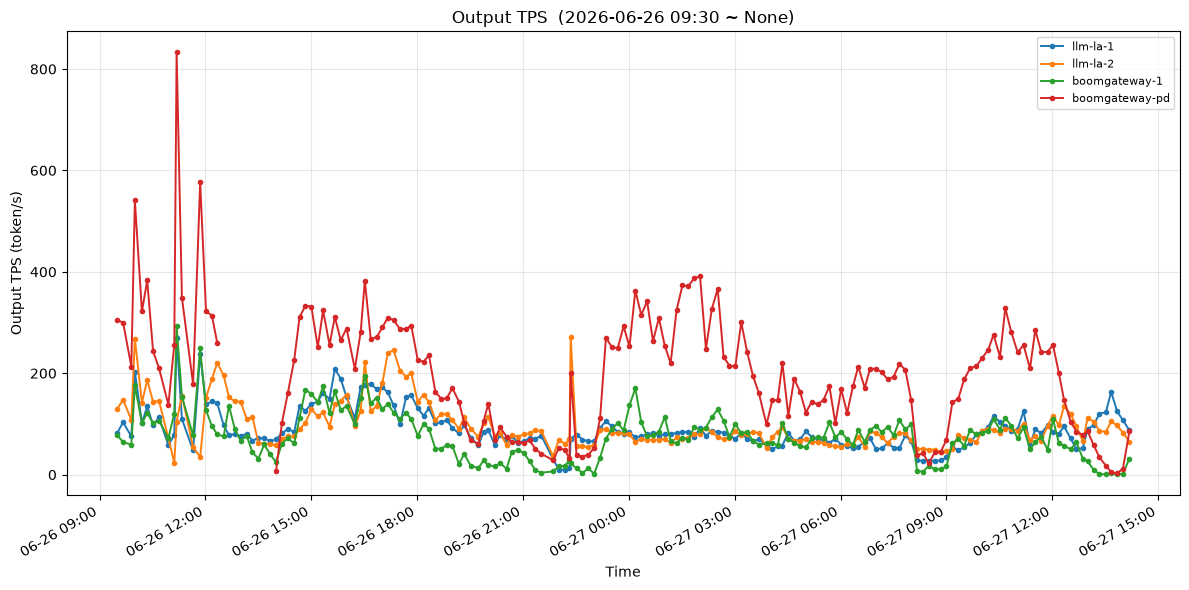

In [21]:
# ============================================================
# Cell 1 — TPS line chart over a time window
# ============================================================
START = "2026-06-26 09:30"    # set to None for no lower bound
END   = None #"2026-06-25 16:00"    # set to None for no upper bound

# Display-name mapping: raw model name -> label shown on the plot
LABELS = {
    "MiniMax-M2.7-llmla1-direct65": "llm-la-1",
    "MiniMax-M2.7-llmla2-direct65": "llm-la-2",
    "MiniMax-M2.7-direct142":       "boomgateway-1",
    "MiniMax-M2.7-direct202":       "boomgateway-pd",
}
def label_of(m):
    return LABELS.get(m, m)   # fall back to raw name if not mapped

start, end = parse_window(START), parse_window(END)
tps = filter_window(build_tps(MODELS), start, end)

plt.figure(figsize=(12, 6))
for m, pts in tps.items():
    if not pts:
        print(f"[warn] {label_of(m)}: no data in window"); continue
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):   # break across gaps
        line, = plt.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                         color=c, label=label_of(m) if c is None else None)
        c = line.get_color()
    print(f"[ok] {label_of(m)}: {len(pts)} points")

plt.xlabel("Time"); plt.ylabel("Output TPS (token/s)")
plt.title(f"Output TPS  ({START} ~ {END})")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate(); plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# Cell — avg output tokens per request, over a time window
# Explains why a backend can rank high on TPS but low on request count:
#   TPS ~ (#requests * avg_tokens_per_request) / time
# A high TPS + low request count means few-but-long requests.
# Uses stored snapshots (Cell 0 helpers). Window optional.
# ============================================================
START = "2026-06-26 09:30"
END   = None    # set to None for no upper bound

start, end = parse_window(START), parse_window(END)

def per_request_stats(models, start, end):
    """For each model over the window:
       output_tokens increment (adjacent diff of cumulative) summed,
       finished requests (request_increment) summed."""
    out_tot = {m: 0.0 for m in models}
    req_tot = {m: 0.0 for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            out = v.get("output_tokens") or []
            req = v.get("request_increment") or []
            n = min(len(out), len(req), len(ts_dt))
            for i in range(1, n):
                t = ts_dt[i]
                if t is None: continue
                if (start and t < start) or (end and t > end): continue
                if out[i] is not None and out[i-1] is not None:
                    d_out = out[i] - out[i-1]
                    if d_out > 0:
                        out_tot[m] += d_out
                if req[i] is not None and req[i] > 0:
                    req_tot[m] += req[i]
    return out_tot, req_tot

out_tot, req_tot = per_request_stats(MODELS, start, end)

print(f"{'model':<16}{'finished_req':>14}{'output_tokens':>16}{'avg_tok/req':>14}")
print("-" * 60)
for m in MODELS:
    req = req_tot[m]; tok = out_tot[m]
    per = (tok / req) if req else 0
    print(f"{label_of(m):<16}{req:>14.0f}{tok:>16.0f}{per:>14.1f}")

model             finished_req   output_tokens   avg_tok/req
------------------------------------------------------------
llm-la-1               1559899      1676865420        1075.0
llm-la-2               1277576      1809264774        1416.2
boomgateway-1          2738343      1448273816         528.9
boomgateway-pd         6250248      3444181951         551.0


[ok] llm-la-1: mean output TPS = 89.7  (n=172)
[ok] llm-la-2: mean output TPS = 96.3  (n=172)
[ok] boomgateway-1: mean output TPS = 75.9  (n=172)
[ok] boomgateway-pd: mean output TPS = 200.8  (n=163)


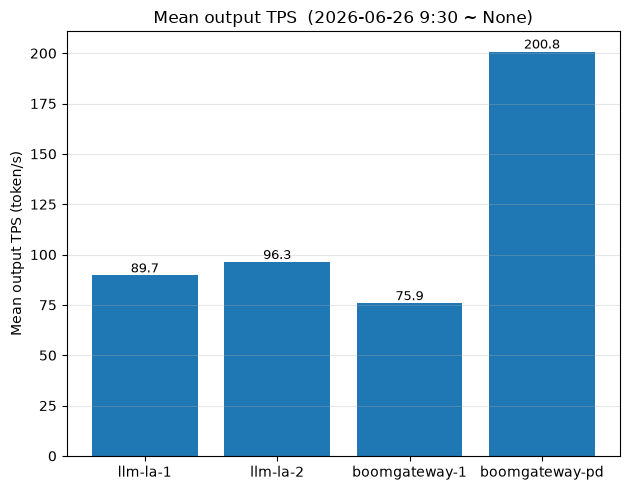

In [23]:
# ============================================================
# Cell 2 — TPS bar chart: mean output TPS per model over the window
# ============================================================
START = "2026-06-26 9:30"    # set to None for no lower bound
END   = None    # set to None for no upper bound

# Display-name mapping: raw model name -> label shown on the plot
LABELS = {
    "MiniMax-M2.7-llmla1-direct65": "llm-la-1",
    "MiniMax-M2.7-llmla2-direct65": "llm-la-2",
    "MiniMax-M2.7-direct142":       "boomgateway-1",
    "MiniMax-M2.7-direct202":       "boomgateway-pd",
}
def label_of(m):
    return LABELS.get(m, m)   # fall back to raw name if not mapped

start, end = parse_window(START), parse_window(END)
tps = filter_window(build_tps(MODELS), start, end)

names, means = [], []
for m in MODELS:
    pts = tps.get(m, {})
    if not pts:
        print(f"[warn] {label_of(m)}: no data"); continue
    mean = sum(pts.values()) / len(pts)
    names.append(label_of(m))
    means.append(mean)
    print(f"[ok] {label_of(m)}: mean output TPS = {mean:.1f}  (n={len(pts)})")

plt.figure(figsize=(max(6, len(names) * 1.6), 5))
bars = plt.bar(names, means)
for r in bars:
    plt.text(r.get_x() + r.get_width()/2, r.get_height(),
             f"{r.get_height():.1f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Mean output TPS (token/s)")
plt.title(f"Mean output TPS  ({START} ~ {END})")
plt.grid(True, axis="y", alpha=0.3); plt.tight_layout()
plt.show()

[ok] MiniMax-M2.7-llmla1-direct65: 352 points
[ok] MiniMax-M2.7-llmla2-direct65: 352 points
[ok] MiniMax-M2.7-direct142: 352 points
[ok] MiniMax-M2.7-direct202: 343 points


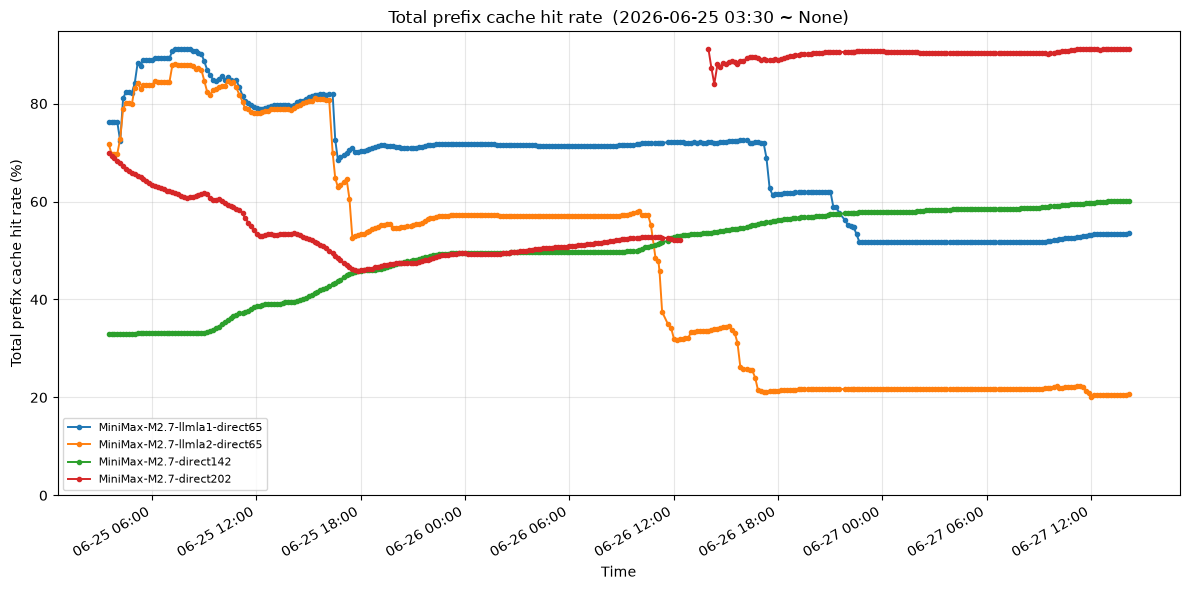

In [24]:
# ============================================================
# Cell 3 — Total prefix cache hit rate line chart over a time window
# ============================================================
START = "2026-06-25 03:30"    # set to None for no lower bound
END   = None    # set to None for no upper bound
start, end = parse_window(START), parse_window(END)
cache = filter_window(build_cache(MODELS), start, end)
plt.figure(figsize=(12, 6))
for m, pts in cache.items():
    if not pts:
        print(f"[warn] {m}: no data in window"); continue
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = plt.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                         color=c, label=m if c is None else None)
        c = line.get_color()
    print(f"[ok] {m}: {len(pts)} points")
plt.xlabel("Time"); plt.ylabel("Total prefix cache hit rate (%)")
plt.title(f"Total prefix cache hit rate  ({START} ~ {END})")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate(); plt.tight_layout()
plt.ylim(bottom=0)
plt.show()

[ok] MiniMax-M2.7-llmla1-direct65: mean cache hit = 65.9%  (n=317)
[ok] MiniMax-M2.7-llmla2-direct65: mean cache hit = 42.9%  (n=317)
[ok] MiniMax-M2.7-direct142: mean cache hit = 51.8%  (n=317)
[ok] MiniMax-M2.7-direct202: mean cache hit = 69.7%  (n=308)


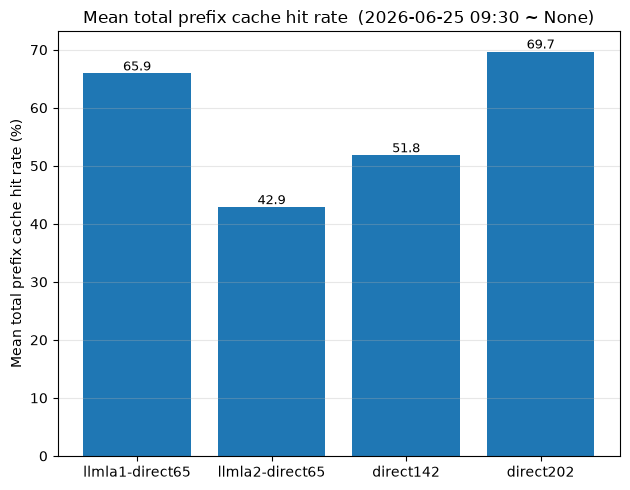

In [25]:
# ============================================================
# Cell 4 — Cache bar chart: mean total prefix cache hit rate per model
# ============================================================
START = "2026-06-25 09:30"    # set to None for no lower bound
END   = None    # set to None for no upper bound

start, end = parse_window(START), parse_window(END)
cache = filter_window(build_cache(MODELS), start, end)

names, means = [], []
for m in MODELS:
    pts = cache.get(m, {})
    if not pts:
        print(f"[warn] {m}: no data"); continue
    mean = sum(pts.values()) / len(pts)
    names.append(m.replace("MiniMax-M2.7-", ""))
    means.append(mean)
    print(f"[ok] {m}: mean cache hit = {mean:.1f}%  (n={len(pts)})")

plt.figure(figsize=(max(6, len(names) * 1.6), 5))
bars = plt.bar(names, means)
for r in bars:
    plt.text(r.get_x() + r.get_width()/2, r.get_height(),
             f"{r.get_height():.1f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Mean total prefix cache hit rate (%)")
plt.title(f"Mean total prefix cache hit rate  ({START} ~ {END})")
plt.grid(True, axis="y", alpha=0.3); plt.tight_layout()
plt.show()

[ok] MiniMax-M2.7-llmla2-direct65: 317 points
[ok] MiniMax-M2.7-direct142: 317 points


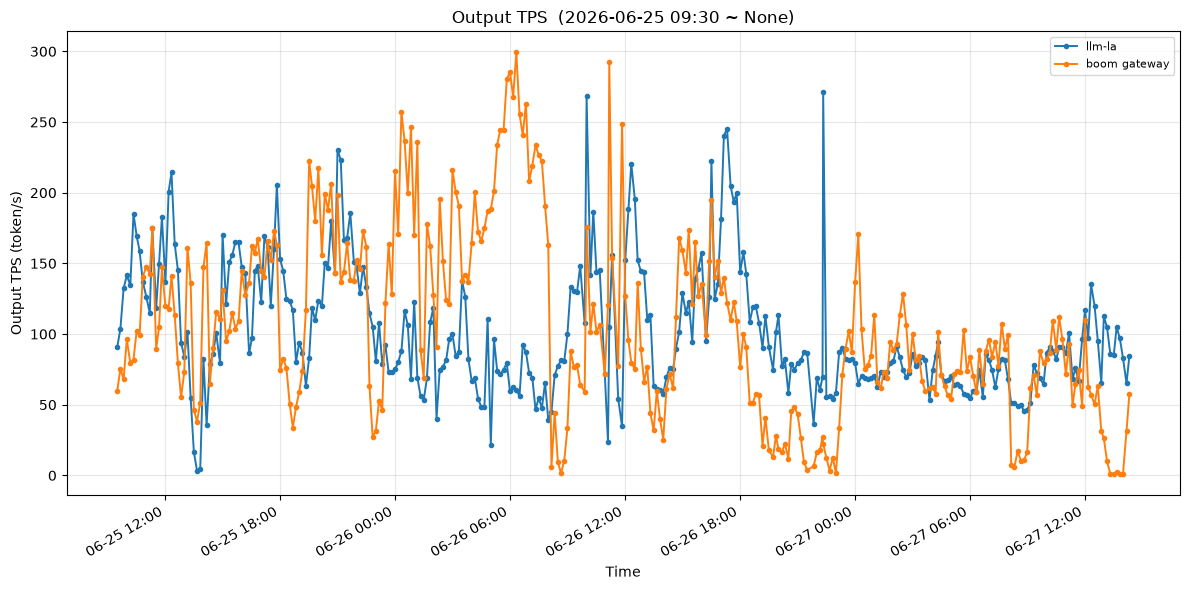

In [26]:
# ============================================================
# Cell 1 — TPS line chart over a time window
# ============================================================
START = "2026-06-25 09:30"    # set to None for no lower bound
END   = None #"2026-06-25 16:00"    # set to None for no upper bound
start, end = parse_window(START), parse_window(END)
tps = filter_window(build_tps(MODELS), start, end)

DISPLAY = {
    "MiniMax-M2.7-llmla2-direct65": "llm-la",
    "MiniMax-M2.7-direct142":       "boom gateway",
}

plt.figure(figsize=(12, 6))
for m, pts in tps.items():
    if m not in DISPLAY:
        continue
    if not pts:
        print(f"[warn] {m}: no data in window"); continue
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = plt.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                         color=c, label=DISPLAY[m] if c is None else None)
        c = line.get_color()
    print(f"[ok] {m}: {len(pts)} points")
plt.xlabel("Time"); plt.ylabel("Output TPS (token/s)")
plt.title(f"Output TPS  ({START} ~ {END})")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate(); plt.tight_layout()
plt.show()

[ok] MiniMax-M2.7-llmla2-direct65: 317 points, mean=101.3
[ok] MiniMax-M2.7-direct142: 317 points, mean=105.4


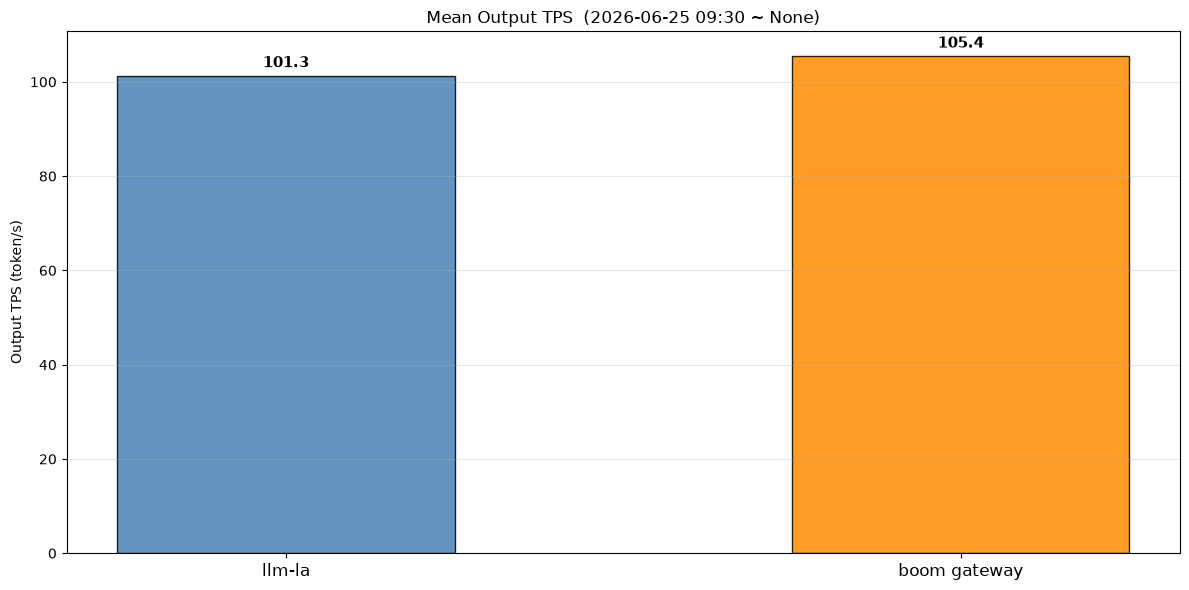

In [27]:
# ============================================================
# Cell 1 — TPS bar chart over a time window
# ============================================================
START = "2026-06-25 09:30"
END   = None #"2026-06-25 16:00"    # set to None for no upper bound
start, end = parse_window(START), parse_window(END)
tps = filter_window(build_tps(MODELS), start, end)

DISPLAY = {
    "MiniMax-M2.7-llmla2-direct65": "llm-la",
    "MiniMax-M2.7-direct142":       "boom gateway",
}

import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

labels, means = [], []
for m, label in DISPLAY.items():
    pts = tps.get(m, {})
    if not pts:
        print(f"[warn] {m}: no data in window"); continue
    vals = list(pts.values())
    labels.append(label)
    means.append(np.mean(vals))
    print(f"[ok] {m}: {len(vals)} points, mean={means[-1]:.1f}")

x = np.arange(len(labels))
bars = ax.bar(x, means, width=0.5,
              color=["steelblue", "darkorange"], alpha=0.85, edgecolor="black")

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{mean:.1f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Output TPS (token/s)"); ax.set_ylim(bottom=0)
ax.set_title(f"Mean Output TPS  ({START} ~ {END})")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

[ok] llm-la-1: 73 points
[ok] llm-la-2: 73 points
[ok] boomgateway-1: 73 points
[ok] boomgateway-pd: 73 points


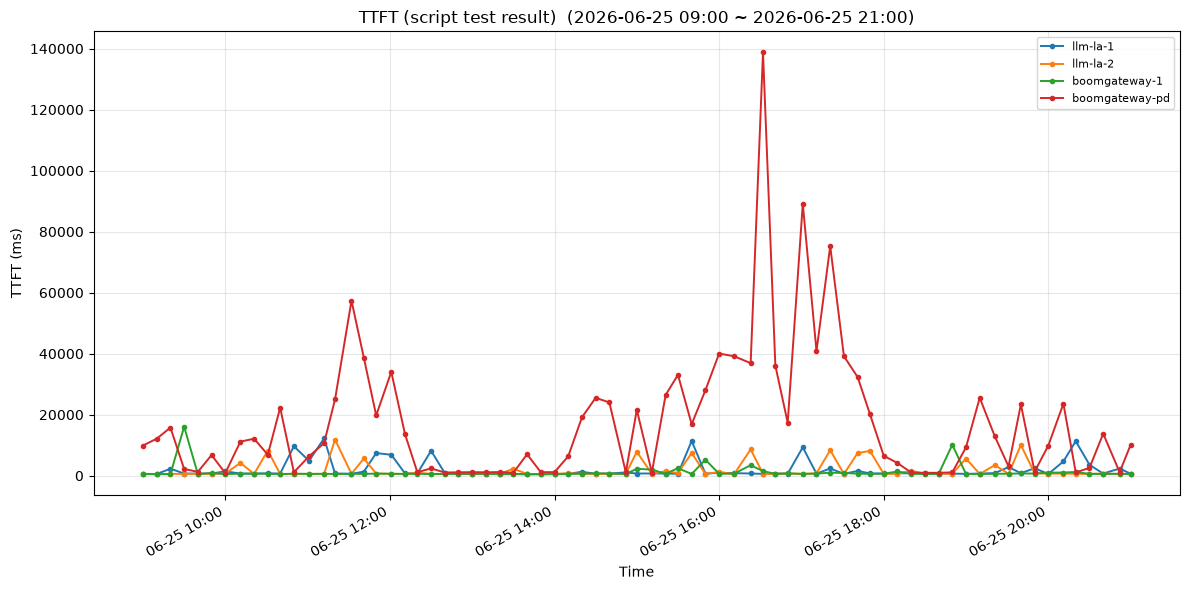

[ok] llm-la-1: mean TTFT = 1976.2 ms  (n=73)
[ok] llm-la-2: mean TTFT = 1902.8 ms  (n=73)
[ok] boomgateway-1: mean TTFT = 1175.9 ms  (n=73)
[ok] boomgateway-pd: mean TTFT = 17650.7 ms  (n=73)


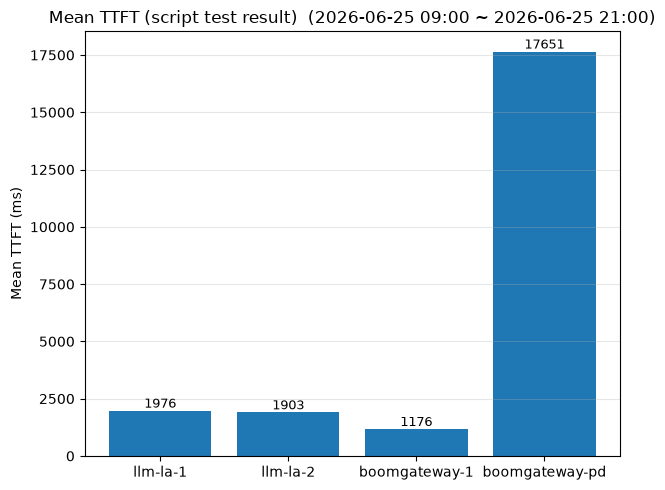

In [28]:
# ============================================================
# Cell 5 — TTFT (script test result) over a time window
# Field: identifier_metrics[model]["ttft"]  (milliseconds)
#
# NOTE: this is the `ttft` field from the data API, which is produced by the
# benchmark script (test_and_collect.py) and surfaced through /api/data.
# It is a DIRECT latency value (ms), NOT a rate -> we take the value as-is,
# no diff/time like TPS.
# CAVEAT: not yet 100% verified to equal the page's "TTFT (script test result)"
# panel free of vLLM-metrics mixing; the field name matches but the DB->API
# mapping was not value-checked. Treat as the data-API ttft field.
# ============================================================
START = "2026-06-25 09:00"
END   = "2026-06-25 21:00"    # set to None for no upper bound

# Display-name mapping: raw model name -> label shown on the plot
LABELS = {
    "MiniMax-M2.7-llmla1-direct65": "llm-la-1",
    "MiniMax-M2.7-llmla2-direct65": "llm-la-2",
    "MiniMax-M2.7-direct142":       "boomgateway-1",
    "MiniMax-M2.7-direct202":       "boomgateway-pd",
}
def label_of(m):
    return LABELS.get(m, m)   # fall back to raw name if not mapped

def build_ttft(models):
    """Return {model: {datetime: ttft_ms}} taken directly from the ttft field."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            ttft = v.get("ttft") or []
            n = min(len(ttft), len(ts_dt))
            for i in range(n):
                if ts_dt[i] is None or ttft[i] is None: continue
                series[m][ts_dt[i]] = round(ttft[i], 2)
    return series

start, end = parse_window(START), parse_window(END)
ttft = filter_window(build_ttft(MODELS), start, end)

# ---- line chart ----
plt.figure(figsize=(12, 6))
for m, pts in ttft.items():
    if not pts:
        print(f"[warn] {label_of(m)}: no data in window"); continue
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = plt.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                         color=c, label=label_of(m) if c is None else None)
        c = line.get_color()
    print(f"[ok] {label_of(m)}: {len(pts)} points")
plt.xlabel("Time"); plt.ylabel("TTFT (ms)")
plt.title(f"TTFT (script test result)  ({START} ~ {END})")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate(); plt.tight_layout()
plt.show()

# ---- bar chart: mean TTFT over the window ----
names, means = [], []
for m in MODELS:
    pts = ttft.get(m, {})
    if not pts:
        print(f"[warn] {label_of(m)}: no data"); continue
    mean = sum(pts.values()) / len(pts)
    names.append(label_of(m))
    means.append(mean)
    print(f"[ok] {label_of(m)}: mean TTFT = {mean:.1f} ms  (n={len(pts)})")

plt.figure(figsize=(max(6, len(names) * 1.6), 5))
bars = plt.bar(names, means)
for r in bars:
    plt.text(r.get_x() + r.get_width()/2, r.get_height(),
             f"{r.get_height():.0f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Mean TTFT (ms)")
plt.title(f"Mean TTFT (script test result)  ({START} ~ {END})")
plt.grid(True, axis="y", alpha=0.3); plt.tight_layout()
plt.show()

[ok] llm-la-1: 299 points
[ok] llm-la-2: 299 points
[ok] boomgateway-1: 299 points
[ok] boomgateway-pd: 299 points


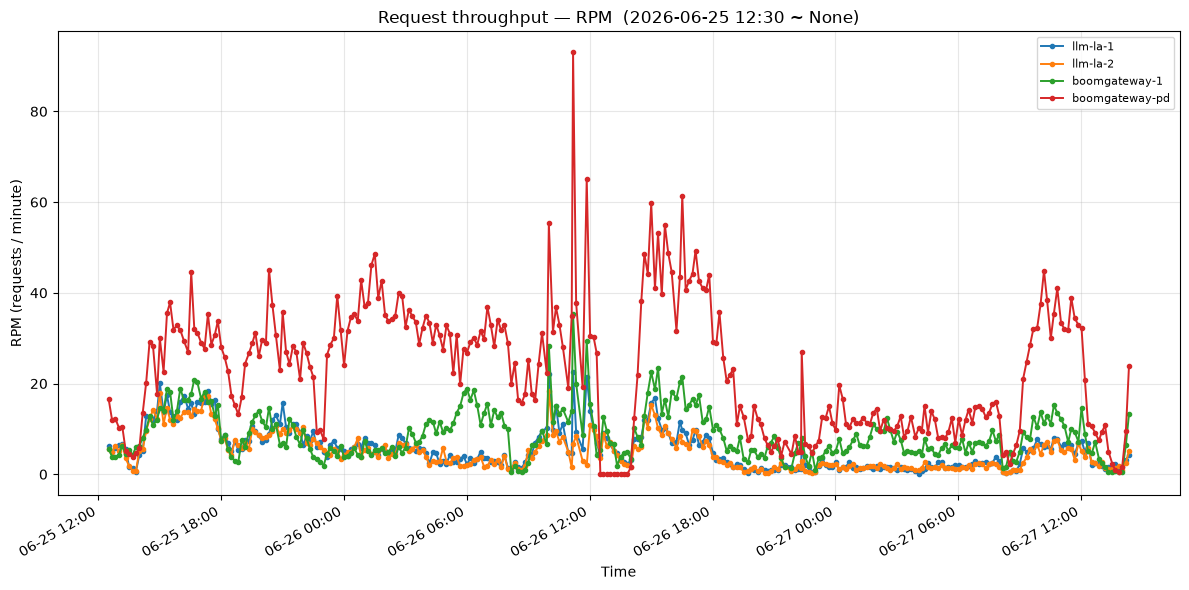

In [29]:
# ============================================================
# Cell A — RPM (requests per minute) line chart over a time window
# RPM = request_increment / actual_minutes_between_adjacent_timestamps
#   (request_increment = number of successfully finished requests in the window,
#    from vllm:request_success_total adjacent diff)
# (uses the real minute span, not a fixed 10, since datapoints are 10~11 min apart)
# ============================================================
START = "2026-06-25 12:30"
END   = None #"2026-06-25 21:00"    # set to None for no upper bound

# Display-name mapping: raw model name -> label shown on the plot
LABELS = {
    "MiniMax-M2.7-llmla1-direct65": "llm-la-1",
    "MiniMax-M2.7-llmla2-direct65": "llm-la-2",
    "MiniMax-M2.7-direct142":       "boomgateway-1",
    "MiniMax-M2.7-direct202":       "boomgateway-pd",
}
def label_of(m):
    return LABELS.get(m, m)   # fall back to raw name if not mapped

def build_rpm(models):
    """Return {model: {datetime: rpm}} = request_increment / minutes_in_window."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            incr = v.get("request_increment") or []
            n = min(len(incr), len(ts_dt))
            for i in range(1, n):                 # need previous ts for the minute span
                if ts_dt[i] is None or ts_dt[i-1] is None: continue
                if incr[i] is None: continue
                minutes = (ts_dt[i] - ts_dt[i-1]).total_seconds() / 60.0
                if minutes <= 0: continue
                series[m][ts_dt[i]] = round(incr[i] / minutes, 2)
    return series

start, end = parse_window(START), parse_window(END)
rpm = filter_window(build_rpm(MODELS), start, end)

plt.figure(figsize=(12, 6))
for m, pts in rpm.items():
    if not pts:
        print(f"[warn] {label_of(m)}: no data in window"); continue
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = plt.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                         color=c, label=label_of(m) if c is None else None)
        c = line.get_color()
    print(f"[ok] {label_of(m)}: {len(pts)} points")

plt.xlabel("Time"); plt.ylabel("RPM (requests / minute)")
plt.title(f"Request throughput — RPM  ({START} ~ {END})")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate(); plt.tight_layout()
plt.show()

[ok] llm-la-1: mean RPM = 5.9  (n=320)
[ok] llm-la-2: mean RPM = 5.2  (n=320)
[ok] boomgateway-1: mean RPM = 9.0  (n=320)
[ok] boomgateway-pd: mean RPM = 23.2  (n=320)


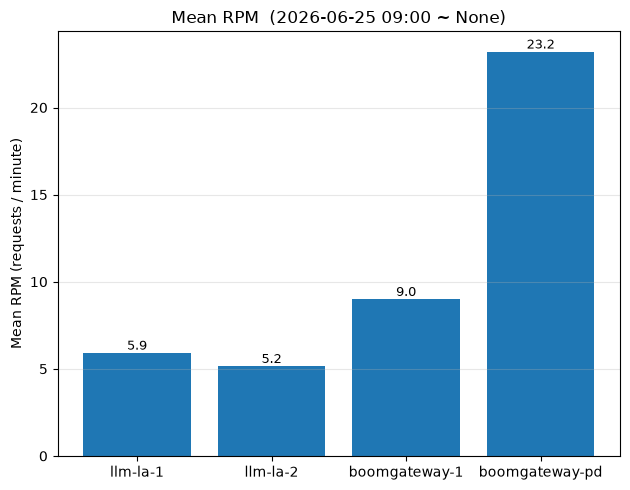

In [30]:
# ============================================================
# Cell B — RPM bar chart: mean RPM per model over the window
# ============================================================
START = "2026-06-25 09:00"
END   = None #"2026-06-25 21:00"    # set to None for no upper bound

start, end = parse_window(START), parse_window(END)
rpm = filter_window(build_rpm(MODELS), start, end)

names, means = [], []
for m in MODELS:
    pts = rpm.get(m, {})
    if not pts:
        print(f"[warn] {label_of(m)}: no data"); continue
    mean = sum(pts.values()) / len(pts)
    names.append(label_of(m))
    means.append(mean)
    print(f"[ok] {label_of(m)}: mean RPM = {mean:.1f}  (n={len(pts)})")

plt.figure(figsize=(max(6, len(names) * 1.6), 5))
bars = plt.bar(names, means)
for r in bars:
    plt.text(r.get_x() + r.get_width()/2, r.get_height(),
             f"{r.get_height():.1f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Mean RPM (requests / minute)")
plt.title(f"Mean RPM  ({START} ~ {END})")
plt.grid(True, axis="y", alpha=0.3); plt.tight_layout()
plt.show()

[ok] llm-la-1: 320 points
[ok] llm-la-2: 320 points
[ok] boomgateway-1: 320 points
[ok] boomgateway-pd: 320 points


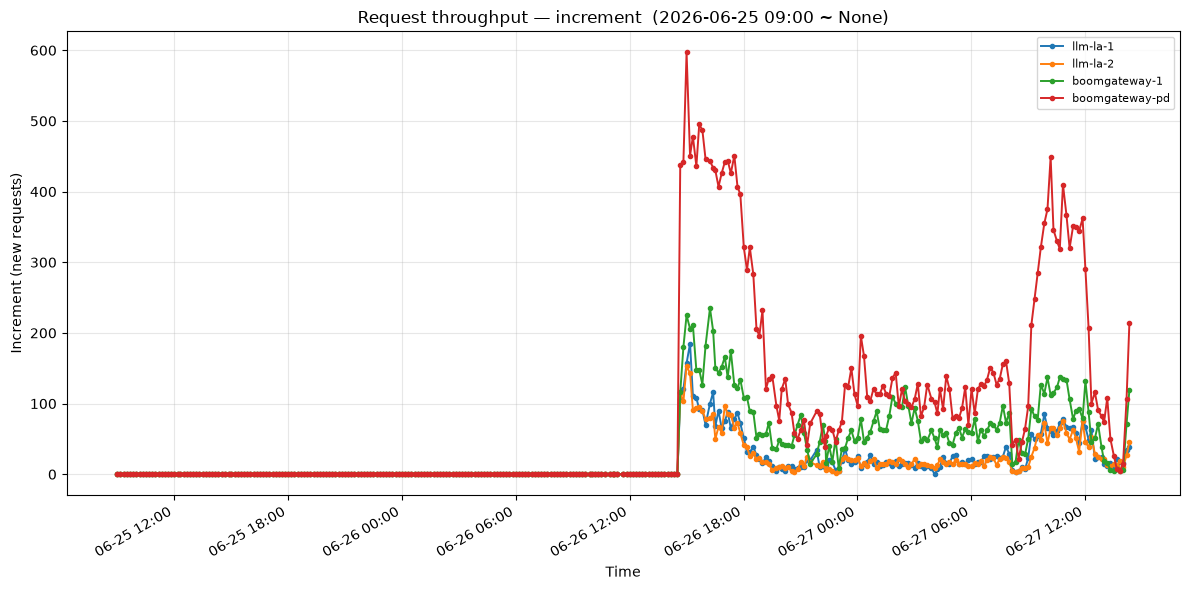

In [31]:
# ============================================================
# Cell C — Increment (new requests per datapoint) line chart over a window
# Source: identifier_metrics[model]["request_increment"] (raw, taken as-is)
#   request_increment = successfully finished requests in the window
#   (vllm:request_success_total adjacent diff)
# ============================================================
START = "2026-06-25 09:00"
END   = None #"2026-06-25 21:00"    # set to None for no upper bound

def build_increment(models):
    """Return {model: {datetime: request_increment}} taken directly."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            incr = v.get("request_increment") or []
            n = min(len(incr), len(ts_dt))
            for i in range(n):
                if ts_dt[i] is None or incr[i] is None: continue
                series[m][ts_dt[i]] = incr[i]
    return series

start, end = parse_window(START), parse_window(END)
inc = filter_window(build_increment(MODELS), start, end)

plt.figure(figsize=(12, 6))
for m, pts in inc.items():
    if not pts:
        print(f"[warn] {label_of(m)}: no data in window"); continue
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = plt.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                         color=c, label=label_of(m) if c is None else None)
        c = line.get_color()
    print(f"[ok] {label_of(m)}: {len(pts)} points")

plt.xlabel("Time"); plt.ylabel("Increment (new requests)")
plt.title(f"Request throughput — increment  ({START} ~ {END})")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate(); plt.tight_layout()
plt.show()

[ok] llm-la-1: mean increment = 15.6  (n=320)
[ok] llm-la-2: mean increment = 14.0  (n=320)
[ok] boomgateway-1: mean increment = 34.9  (n=320)
[ok] boomgateway-pd: mean increment = 83.1  (n=320)


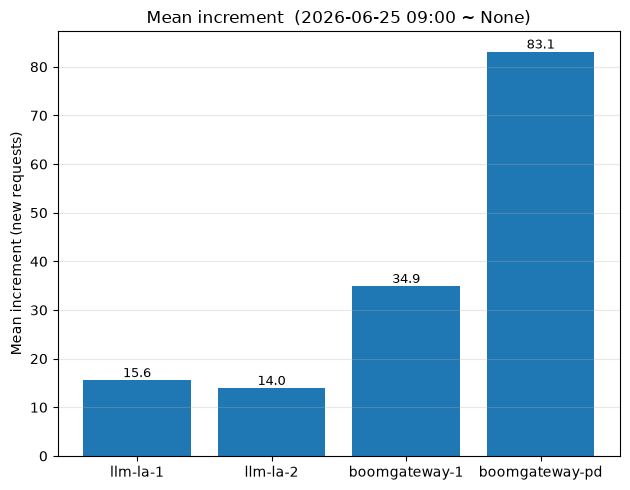

In [32]:
# ============================================================
# Cell D — Increment bar chart: mean increment per model over the window
# ============================================================
START = "2026-06-25 09:00"
END   = None #"2026-06-25 21:00"    # set to None for no upper bound

start, end = parse_window(START), parse_window(END)
inc = filter_window(build_increment(MODELS), start, end)

names, means = [], []
for m in MODELS:
    pts = inc.get(m, {})
    if not pts:
        print(f"[warn] {label_of(m)}: no data"); continue
    mean = sum(pts.values()) / len(pts)
    names.append(label_of(m))
    means.append(mean)
    print(f"[ok] {label_of(m)}: mean increment = {mean:.1f}  (n={len(pts)})")

plt.figure(figsize=(max(6, len(names) * 1.6), 5))
bars = plt.bar(names, means)
for r in bars:
    plt.text(r.get_x() + r.get_width()/2, r.get_height(),
             f"{r.get_height():.1f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Mean increment (new requests)")
plt.title(f"Mean increment  ({START} ~ {END})")
plt.grid(True, axis="y", alpha=0.3); plt.tight_layout()
plt.show()

[ids] logs.endpoint_id : ['vllm-minimax-m2-0', 'vllm-minimax-m2-1']
[ids] metrics.instance : ['7.150.1.218:8200:0', '7.150.1.218:8200:1', '7.150.6.33:8200:0', '7.150.6.33:8200:1']
[ids] plotting instances: ['vllm-minimax-m2-0', 'vllm-minimax-m2-1']
[map] metrics -> endpoint via instance(dp_rank) : ['vllm-minimax-m2-0', 'vllm-minimax-m2-1']


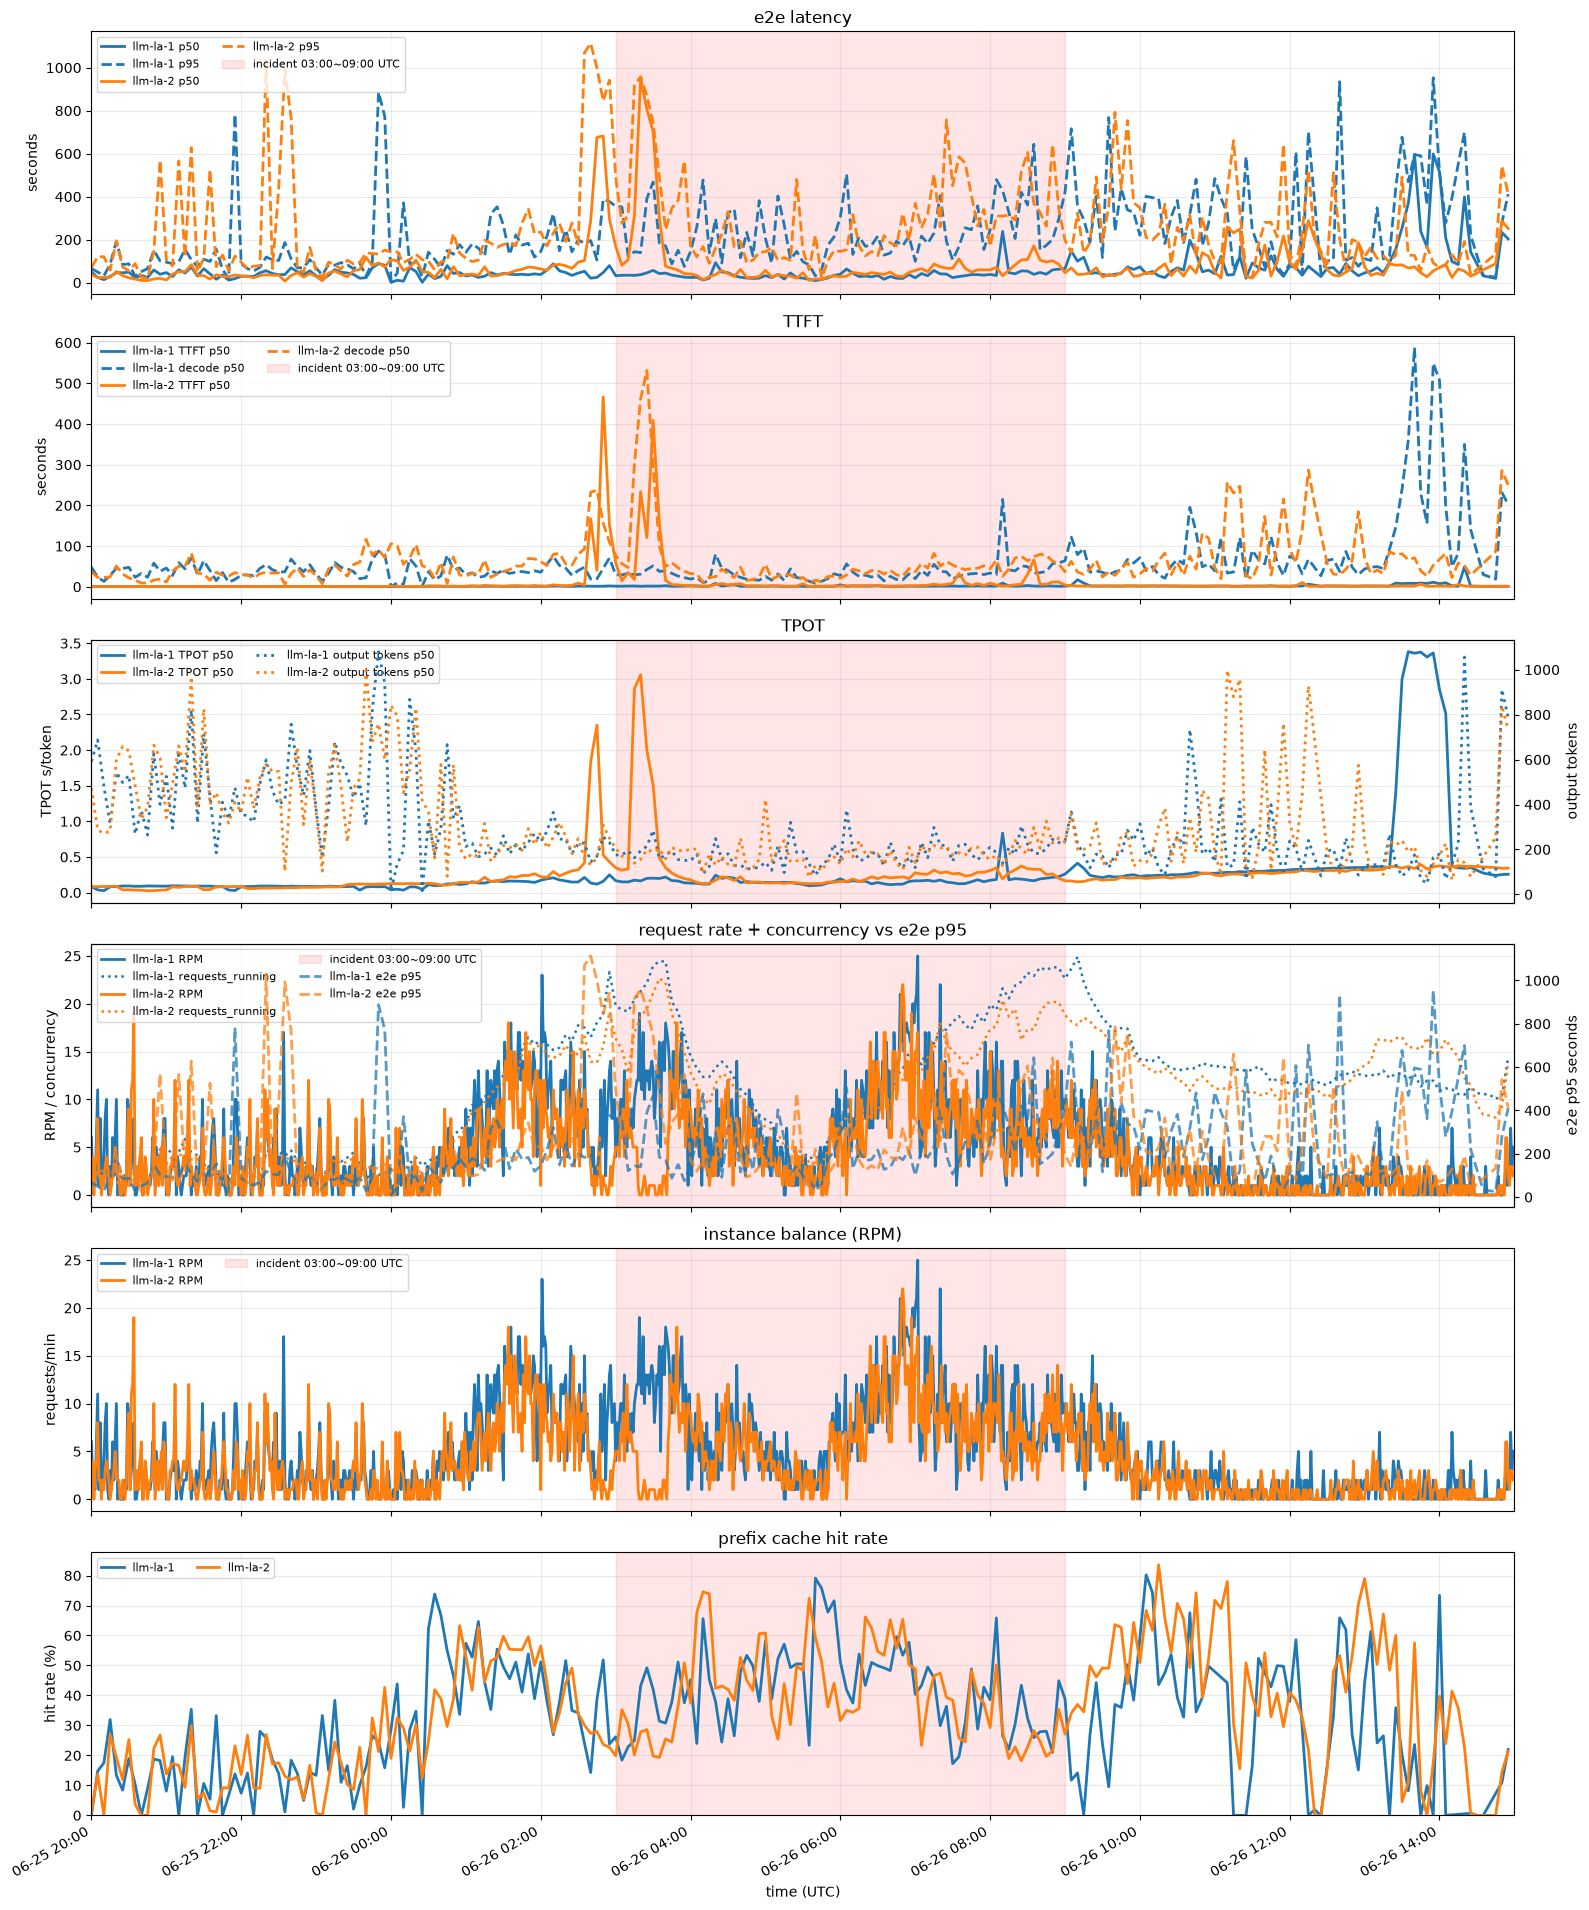

Experiment: 46  dir=/home/data/saeid/experiments/46
Timezone: UTC; baseline=2026-06-26 00:00:00+00:00~2026-06-26 03:00:00+00:00; incident=2026-06-26 03:00:00+00:00~2026-06-26 09:00:00+00:00
Request fields: {'end_to_end_s': np.True_, 'ttft_s': np.True_, 'tpot_avg_s': np.True_, 'completion_tokens': np.True_}
Metrics group col: instance(dp_rank) ; concurrency: ['requests_running', 'requests_waiting', 'router_queue_length'] ; cache: prefix_cache_hit_rate


,instance,metric,baseline_p50,incident_p50,p50_change_%,baseline_p95,incident_p95,p95_change_%
0,llm-la-1,e2e_seconds,40.946,34.357,-16.093,230.325,254.093,10.319
1,llm-la-1,ttft_seconds,1.347,1.693,25.675,12.184,12.346,1.333
2,llm-la-1,tpot_seconds_per_token,0.152,0.159,4.358,0.281,0.295,4.773
3,llm-la-1,output_tokens,230.500,175.000,-24.078,1218.750,1324.000,8.636
4,llm-la-1,RPM,7.000,8.000,14.286,15.150,17.000,12.211
5,llm-la-1,prefix_cache_hit_rate_percent,40.711,33.492,-17.732,99.180,99.002,-0.180
6,llm-la-2,e2e_seconds,58.854,53.492,-9.111,300.022,348.778,16.251
7,llm-la-2,ttft_seconds,2.030,3.636,79.137,26.436,58.724,122.136
8,llm-la-2,tpot_seconds_per_token,0.216,0.227,5.266,0.471,0.434,-7.973
9,llm-la-2,output_tokens,223.000,176.000,-21.076,959.000,1132.300,18.071


In [40]:
# Locate the 2026-06-26 03:00~09:00 e2e-latency rise by aligned time-series panels.
# Two data sources of DIFFERENT granularity, never row-merged:
#   per-request latencies <- logs.json   (grouped by endpoint_id, e.g. vllm-minimax-m2-0/1)
#   prometheus samples    <- ambient df  (instance="IP:port:dp_rank", bridged via server_slot)
# Log timestamps are epoch seconds (time.time()); metric timestamps are UTC ISO.
# All windows are interpreted and plotted in UTC.

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

try:
    from experiment_analysis import load_experiment_latencies, load_experiment_prom_samples
except Exception:
    load_experiment_latencies = globals().get("load_experiment_latencies")
    load_experiment_prom_samples = globals().get("load_experiment_prom_samples")

EXP_ID = globals().get("EXP_ID", globals().get("exp_id", 42))
EXPERIMENTS_ROOT = globals().get("EXPERIMENTS_ROOT", "/home/data/saeid/experiments")
EXP_DIR = Path(EXPERIMENTS_ROOT) / str(EXP_ID)

LOG_TZ = "UTC"
PLOT_START = pd.Timestamp("2026-06-25 20:00", tz=LOG_TZ)
PLOT_END = pd.Timestamp("2026-06-26 15:00", tz=LOG_TZ)
BASE_START = pd.Timestamp("2026-06-26 00:00", tz=LOG_TZ)
BASE_END = pd.Timestamp("2026-06-26 03:00", tz=LOG_TZ)
INC_START = pd.Timestamp("2026-06-26 03:00", tz=LOG_TZ)
INC_END = pd.Timestamp("2026-06-26 09:00", tz=LOG_TZ)

INSTANCE_ORDER = ["vllm-minimax-m2-0", "vllm-minimax-m2-1"]
INSTANCE_LABELS = {
    "vllm-minimax-m2-0": "llm-la-1",
    "vllm-minimax-m2-1": "llm-la-2",
}
INSTANCE_COLORS = {
    "vllm-minimax-m2-0": "tab:blue",
    "vllm-minimax-m2-1": "tab:orange",
}
ROLL_FREQ = "5min"

def _read_ndjson(path):
    rows = []
    if not path.is_file():
        return rows
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows

def _read_raw_logs(exp_dir):
    paths = [exp_dir / "logs.json"] + sorted(exp_dir.glob("logs_*.json"))
    rows = []
    for p in paths:
        rows.extend(_read_ndjson(p))
    return pd.DataFrame(rows)

def _epoch_to_utc_datetime(s):
    vals = pd.to_numeric(s, errors="coerce")
    med = vals.dropna().abs().median()
    unit = "s"
    if pd.notna(med) and med > 1e17:
        unit = "ns"
    elif pd.notna(med) and med > 1e11:
        unit = "ms"
    return pd.to_datetime(vals, unit=unit, utc=True, errors="coerce")

def _label(inst):
    return INSTANCE_LABELS.get(inst, str(inst))

def _color(inst):
    return INSTANCE_COLORS.get(inst, None)

def _window(df0, start, end, time_col="ts"):
    return df0[(df0[time_col] >= start) & (df0[time_col] < end)].copy()

def _resample_quantile(df0, value_col, q, freq=ROLL_FREQ):
    if df0.empty or value_col not in df0.columns:
        return pd.Series(dtype=float)
    return (df0.set_index("ts")[value_col].sort_index().astype(float)
            .resample(freq).quantile(q).dropna())

def _resample_median(df0, value_col, freq=ROLL_FREQ):
    if df0.empty or value_col not in df0.columns:
        return pd.Series(dtype=float)
    return (df0.set_index("ts")[value_col].sort_index().astype(float)
            .resample(freq).median().dropna())

def _resample_mean(df0, value_col, freq=ROLL_FREQ):
    if df0.empty or value_col not in df0.columns:
        return pd.Series(dtype=float)
    return (df0.set_index("ts")[value_col].sort_index().astype(float)
            .resample(freq).mean().dropna())

def _rpm_series(df0, freq="1min"):
    if df0.empty:
        return pd.Series(dtype=float)
    return df0.set_index("ts")["req_id"].resample(freq).count().astype(float)

def _available_numeric(df0, col):
    return (not df0.empty) and (col in df0.columns) and pd.to_numeric(df0[col], errors="coerce").notna().any()

# ============================================================================
# Data acquisition. The two sources share no row key by design -> never merge.
# ============================================================================

# --- per-request frame: authoritative per-request latencies (logs.json) ---
req = _read_raw_logs(EXP_DIR)
if req.empty and load_experiment_latencies is not None:
    try:
        req = load_experiment_latencies(exp_id=EXP_ID, experiments_root=EXPERIMENTS_ROOT)
    except Exception as e:
        raise RuntimeError(f"logs.json empty and load_experiment_latencies failed: {e}")
if req.empty:
    raise RuntimeError(f"No per-request logs under {EXP_DIR} (logs.json / logs_*.json).")
if "t0_wall" not in req.columns:
    raise RuntimeError(f"t0_wall missing in per-request logs; columns={sorted(req.columns)}")

if "endpoint_id" not in req.columns:
    for fb in ["serving_pod", "endpoint", "pod", "instance"]:
        if fb in req.columns:
            req["endpoint_id"] = req[fb]
            break
if "endpoint_id" not in req.columns:
    raise RuntimeError("No endpoint_id field in per-request logs; cannot separate instances.")

req["ts"] = _epoch_to_utc_datetime(req["t0_wall"]).dt.tz_convert(LOG_TZ)
if "send_failed" in req.columns:
    req = req[~req["send_failed"].fillna(False)].copy()
for c in ["end_to_end_s", "ttft_s", "tpot_avg_s", "completion_tokens"]:
    if c in req.columns:
        req[c] = pd.to_numeric(req[c], errors="coerce")
req = req.dropna(subset=["ts", "endpoint_id"])
if "req_id" not in req.columns:
    req["req_id"] = np.arange(len(req))

# --- metrics frame: the ambient df is ALREADY the prom-sample frame ---
metrics = pd.DataFrame()
if "df" in globals() and isinstance(df, pd.DataFrame) and "instance" in df.columns:
    metrics = df.copy()
elif load_experiment_prom_samples is not None:
    try:
        metrics = load_experiment_prom_samples(exp_id=EXP_ID, experiments_root=EXPERIMENTS_ROOT)
    except Exception:
        metrics = pd.DataFrame()
if metrics.empty:
    rows = []
    for rec in _read_ndjson(EXP_DIR / "metrics.jsonl"):
        ts = rec.get("ts")
        for sample in rec.get("samples", []) or []:
            if isinstance(sample, dict):
                row = {"ts": ts}; row.update(sample); rows.append(row)
    metrics = pd.DataFrame(rows)

# --- confirm instance identifiers across the two frames ---
log_instances = sorted(req["endpoint_id"].dropna().astype(str).unique())
met_instances = (sorted(metrics["instance"].dropna().astype(str).unique())
                 if (not metrics.empty and "instance" in metrics.columns) else [])
print("[ids] logs.endpoint_id :", log_instances)
print("[ids] metrics.instance :", met_instances)

present_instances = [x for x in INSTANCE_ORDER if x in set(req["endpoint_id"])]
if not present_instances:
    present_instances = log_instances[:2]
print("[ids] plotting instances:", present_instances)

plot_req = _window(req[req["endpoint_id"].isin(present_instances)], PLOT_START, PLOT_END)
if plot_req.empty:
    print(f"[warn] No request rows in {PLOT_START} ~ {PLOT_END}. Available range:",
          req["ts"].min(), "to", req["ts"].max())

# --- bridge metrics to pod names ---
# logs endpoint_id = pod name "vllm-minimax-m2-{N}";
# metrics instance = "IP:8200:dp_rank". Bridge via server_slot (0/1) if present,
# else fall back to the trailing dp_rank in the instance string.
# NOTE: rank-only mapping collapses both physical nodes (.218 / .33) into one slot.
metric_group_col = None
metric_plot = pd.DataFrame()
if not metrics.empty and "ts" in metrics.columns:
    metrics["ts"] = pd.to_datetime(metrics["ts"], utc=True, errors="coerce").dt.tz_convert(LOG_TZ)

    def _slot_to_endpoint(slot):
        try:
            return f"vllm-minimax-m2-{int(slot)}"
        except (ValueError, TypeError):
            return None

    mapped = None
    if "server_slot" in metrics.columns:
        mapped = metrics["server_slot"].map(_slot_to_endpoint)
        metric_group_col = "server_slot"
    if mapped is None or mapped.isna().all():
        if "instance" in metrics.columns:
            rank = metrics["instance"].astype(str).str.rsplit(":", n=1).str[-1]
            mapped = rank.map(_slot_to_endpoint)
            metric_group_col = "instance(dp_rank)"

    if mapped is not None and mapped.notna().any():
        metrics["metric_endpoint"] = mapped
        bridged = sorted(metrics["metric_endpoint"].dropna().unique())
        print("[map] metrics -> endpoint via", metric_group_col, ":", bridged)
        metric_plot = _window(
            metrics[metrics["metric_endpoint"].isin(present_instances)].copy(),
            PLOT_START, PLOT_END,
        )
        for c in ["requests_running", "requests_waiting", "router_queue_length",
                  "sidecar_queue_length", "prefix_cache_hit_rate", "ext_prefix_cache_hit_rate",
                  "router_e2e_p95"]:
            if c in metric_plot.columns:
                metric_plot[c] = pd.to_numeric(metric_plot[c], errors="coerce")
    else:
        metric_group_col = None
        print("[warn] could not bridge metrics.instance to pod names; "
              "concurrency/cache panels will be skipped. "
              f"logs ids={log_instances} vs metrics ids={met_instances}")

has_ttft = _available_numeric(plot_req, "ttft_s")
has_tpot = _available_numeric(plot_req, "tpot_avg_s")
has_out_tokens = _available_numeric(plot_req, "completion_tokens")
concurrency_cols = [c for c in ["requests_running", "requests_waiting", "sidecar_queue_length", "router_queue_length"] if _available_numeric(metric_plot, c)]
cache_col = None
for cand in ["prefix_cache_hit_rate", "ext_prefix_cache_hit_rate"]:
    if _available_numeric(metric_plot, cand):
        cache_col = cand
        break
has_router_e2e = _available_numeric(metric_plot, "router_e2e_p95")

panel_count = 6
fig, axes = plt.subplots(panel_count, 1, figsize=(16, 3.2 * panel_count), sharex=True)
axes = np.atleast_1d(axes)

def _shade(ax):
    ax.axvspan(INC_START, INC_END, color="red", alpha=0.10, label="incident 03:00~09:00 UTC")
    ax.grid(True, alpha=0.25)

# 1. e2e latency: rolling p50/p95 (+ metrics router_e2e_p95 cross-check)
ax = axes[0]
for inst in present_instances:
    d = plot_req[plot_req["endpoint_id"] == inst].sort_values("ts")
    p50 = _resample_quantile(d, "end_to_end_s", 0.50)
    p95 = _resample_quantile(d, "end_to_end_s", 0.95)
    ax.plot(p50.index, p50.values, color=_color(inst), lw=2, label=f"{_label(inst)} p50")
    ax.plot(p95.index, p95.values, color=_color(inst), lw=2, ls="--", label=f"{_label(inst)} p95")
    if has_router_e2e:
        md = metric_plot[metric_plot["metric_endpoint"] == inst].sort_values("ts")
        ax.plot(md["ts"], md["router_e2e_p95"], color=_color(inst), lw=1.2, ls=":",
                alpha=0.7, label=f"{_label(inst)} router p95 (xcheck)")
ax.set_title("e2e latency")
ax.set_ylabel("seconds")
_shade(ax)
ax.legend(loc="upper left", ncol=2, fontsize=8)

# 2. TTFT vs decode time
ax = axes[1]
if has_ttft:
    plot_req["decode_s"] = (plot_req["end_to_end_s"] - plot_req["ttft_s"]).clip(lower=0)
    for inst in present_instances:
        d = plot_req[plot_req["endpoint_id"] == inst].sort_values("ts")
        ttft = _resample_median(d, "ttft_s")
        dec = _resample_median(d, "decode_s")
        ax.plot(ttft.index, ttft.values, color=_color(inst), lw=2, label=f"{_label(inst)} TTFT p50")
        ax.plot(dec.index, dec.values, color=_color(inst), lw=2, ls="--", label=f"{_label(inst)} decode p50")
    ax.set_title("TTFT")
else:
    ax.set_title("TTFT (skipped - field missing)")
    ax.text(0.01, 0.5, "Cannot split prefill/queue vs decode without ttft_s.", transform=ax.transAxes)
ax.set_ylabel("seconds")
_shade(ax)
ax.legend(loc="upper left", ncol=2, fontsize=8)

# 3. TPOT + output tokens
ax = axes[2]
if has_tpot or has_out_tokens:
    ax2 = ax.twinx() if (has_tpot and has_out_tokens) else None
    for inst in present_instances:
        d = plot_req[plot_req["endpoint_id"] == inst].sort_values("ts")
        if has_tpot:
            tpot = _resample_median(d, "tpot_avg_s")
            ax.plot(tpot.index, tpot.values, color=_color(inst), lw=2, label=f"{_label(inst)} TPOT p50")
        if has_out_tokens:
            out = _resample_median(d, "completion_tokens")
            target_ax = ax2 if ax2 is not None else ax
            target_ax.plot(out.index, out.values, color=_color(inst), lw=2, ls=":", label=f"{_label(inst)} output tokens p50")
    ax.set_title("TPOT")
    ax.set_ylabel("TPOT s/token" if has_tpot else "output tokens")
    if ax2 is not None:
        ax2.set_ylabel("output tokens")
        l1, lab1 = ax.get_legend_handles_labels()
        l2, lab2 = ax2.get_legend_handles_labels()
        ax.legend(l1 + l2, lab1 + lab2, loc="upper left", ncol=2, fontsize=8)
    else:
        ax.legend(loc="upper left", ncol=2, fontsize=8)
else:
    ax.set_title("TPOT (skipped - field missing)")
    ax.text(0.01, 0.5, "Cannot normalize by decode speed or output length.", transform=ax.transAxes)
    ax.set_ylabel("n/a")
_shade(ax)

# 4. RPM + concurrency/queue vs e2e p95
ax = axes[3]
axr = ax.twinx()
for inst in present_instances:
    d = plot_req[plot_req["endpoint_id"] == inst].sort_values("ts")
    rpm = _rpm_series(d)
    p95 = _resample_quantile(d, "end_to_end_s", 0.95)
    ax.plot(rpm.index, rpm.values, color=_color(inst), lw=2, label=f"{_label(inst)} RPM")
    axr.plot(p95.index, p95.values, color=_color(inst), lw=2, ls="--", alpha=0.75, label=f"{_label(inst)} e2e p95")
    if concurrency_cols:
        md = metric_plot[metric_plot["metric_endpoint"] == inst].sort_values("ts")
        ccol = concurrency_cols[0]
        conc = _resample_mean(md, ccol)
        ax.plot(conc.index, conc.values, color=_color(inst), lw=1.8, ls=":", label=f"{_label(inst)} {ccol}")
ax.set_title("request rate + concurrency vs e2e p95")
ax.set_ylabel("RPM / concurrency")
axr.set_ylabel("e2e p95 seconds")
_shade(ax)
l1, lab1 = ax.get_legend_handles_labels()
l2, lab2 = axr.get_legend_handles_labels()
ax.legend(l1 + l2, lab1 + lab2, loc="upper left", ncol=2, fontsize=8)

# 5. Per-instance RPM balance
ax = axes[4]
for inst in present_instances:
    d = plot_req[plot_req["endpoint_id"] == inst].sort_values("ts")
    rpm = _rpm_series(d)
    ax.plot(rpm.index, rpm.values, color=_color(inst), lw=2, label=f"{_label(inst)} RPM")
ax.set_title("instance balance (RPM)")
ax.set_ylabel("requests/min")
_shade(ax)
ax.legend(loc="upper left", ncol=2, fontsize=8)

# 6. prefix cache hit rate
ax = axes[5]
if cache_col:
    for inst in present_instances:
        md = metric_plot[metric_plot["metric_endpoint"] == inst].sort_values("ts")
        hit = _resample_mean(md, cache_col) * 100.0
        ax.plot(hit.index, hit.values, color=_color(inst), lw=2, label=f"{_label(inst)}")
    ax.set_title("prefix cache hit rate")
    ax.set_ylabel("hit rate (%)")
    ax.set_ylim(bottom=0)
    ax.legend(loc="upper left", ncol=2, fontsize=8)
else:
    reason = "metrics empty" if metrics.empty else "cache field unavailable or not mapped"
    ax.set_title("prefix cache hit rate (skipped - field missing)")
    ax.text(0.01, 0.5, reason, transform=ax.transAxes)
    ax.set_ylabel("n/a")
_shade(ax)

axes[-1].set_xlim(PLOT_START, PLOT_END)
tz_for_fmt = plot_req["ts"].dt.tz if not plot_req.empty else req["ts"].dt.tz
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M", tz=tz_for_fmt))
axes[-1].set_xlabel(f"time ({LOG_TZ})")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# ============================================================================
# Quant table: baseline 00:00~03:00 vs incident 03:00~09:00.
# ============================================================================
summary_rows = []

def _add_metric_summary(inst, metric, base_values, inc_values):
    base_values = pd.Series(base_values).dropna().astype(float)
    inc_values = pd.Series(inc_values).dropna().astype(float)
    if base_values.empty or inc_values.empty:
        return
    b50, b95 = base_values.quantile(0.50), base_values.quantile(0.95)
    i50, i95 = inc_values.quantile(0.50), inc_values.quantile(0.95)
    summary_rows.append({
        "instance": _label(inst),
        "metric": metric,
        "baseline_p50": b50,
        "incident_p50": i50,
        "p50_change_%": np.nan if b50 == 0 else (i50 / b50 - 1) * 100,
        "baseline_p95": b95,
        "incident_p95": i95,
        "p95_change_%": np.nan if b95 == 0 else (i95 / b95 - 1) * 100,
    })

for inst in present_instances:
    d = req[req["endpoint_id"] == inst].copy()
    base = _window(d, BASE_START, BASE_END)
    inc = _window(d, INC_START, INC_END)
    for col, name in [
        ("end_to_end_s", "e2e_seconds"),
        ("ttft_s", "ttft_seconds"),
        ("tpot_avg_s", "tpot_seconds_per_token"),
        ("completion_tokens", "output_tokens"),
    ]:
        if _available_numeric(d, col):
            _add_metric_summary(inst, name, base[col], inc[col])
    _add_metric_summary(inst, "RPM", _rpm_series(base), _rpm_series(inc))
    if cache_col:
        md = metric_plot[metric_plot["metric_endpoint"] == inst].copy()
        mbase = _window(md, BASE_START, BASE_END)
        minc = _window(md, INC_START, INC_END)
        _add_metric_summary(inst, f"{cache_col}_percent", mbase[cache_col] * 100.0, minc[cache_col] * 100.0)

summary = pd.DataFrame(summary_rows)
if summary.empty:
    print("No summary rows could be computed for the selected windows.")
else:
    print(f"Experiment: {EXP_ID}  dir={EXP_DIR}")
    print(f"Timezone: {LOG_TZ}; baseline={BASE_START}~{BASE_END}; incident={INC_START}~{INC_END}")
    print("Request fields:",
          {c: _available_numeric(req, c) for c in ["end_to_end_s", "ttft_s", "tpot_avg_s", "completion_tokens"]})
    print("Metrics group col:", metric_group_col or "not mapped",
          "; concurrency:", concurrency_cols or "none", "; cache:", cache_col or "none")
    display(summary.round(3))

In [34]:
print("req columns:", list(req.columns))
raw_logs_dbg = _read_raw_logs(EXP_DIR)
print("raw_logs columns:", list(raw_logs_dbg.columns))
print("common:", sorted(set(req.columns) & set(raw_logs_dbg.columns)))

req columns: ['ts', 'instance', 'requests_running', 'requests_waiting', 'request_success_per_sec', 'preemptions_per_sec', 'gen_tokens_per_sec', 'prefill_tokens_per_sec', 'prefix_cache_hits_per_sec', 'prefix_cache_queries_per_sec', 'ext_prefix_cache_hits_per_sec', 'ext_prefix_cache_queries_per_sec', 'prompt_tokens_cached_per_sec', 'ttft_seconds_avg', 'e2e_latency_seconds_avg', 'router_queue_length', 'router_admission_rps', 'router_outgoing_rps', 'prefix_cache_hit_rate', 'ext_prefix_cache_hit_rate', 'sidecar_queue_length', 'sidecar_received_rps', 'sidecar_completed_rps', 'sidecar_workers_total', 'sidecar_workers_busy', 'sidecar_python_threads', 'router_ttft_p50', 'router_ttft_p95', 'router_tpot_avg_p50', 'router_tpot_avg_p95', 'router_e2e_p50', 'router_e2e_p95', 't_rel_s', 'server_slot']
raw_logs columns: ['idx', 'req_id', 't0_wall', 't1_wall', 'end_to_end_s', 'model_latency_s', 'finish_reason', 'endpoint_id', 'streaming', 'prompt_tokens', 'completion_tokens', 'ttft_s', 'tpot_avg_s', 'mo